# Autonomous Enterprise Decision Intelligence Using Agentic AI

**CIS 600 Course Project**

**Ananya Naga Raj** SUID 214585923, **Abhijnya Konanduru Gurumurthy** SUID 231885826, **Amulya Naga Raj** SUID 286373513, **Sunil Hanumanthegowda Kote** SUID 324362001

This notebook implements and evaluates an autonomous enterprise decision intelligence system that monitors structured business metrics, detects anomalies, identifies root causes through contribution based attribution, ranks corrective actions using utility based scoring, and generates structured explanations. The system employs a coordinated multi agent architecture operating within a perception, reasoning, action, feedback loop, governed by a rule based Central Controller and a Shared Memory layer.

**Pipeline stages in execution order**

1. **Monitoring Agent** ingests daily time series metrics and computes rolling mean, rolling standard deviation, and Exponentially Weighted Moving Average
2. **Anomaly Detection Agent** produces a blended z score from rolling and EWMA deviations, computes confidence, and flags anomalies
3. **Root Cause Agent** attributes the deviation across business dimensions using contribution based attribution, ranking each dimension by its proportional share of the observed deviation
4. **Decision Agent** ranks predefined corrective actions from a fixed playbook using a utility function that balances expected impact, risk variance, and operational cost, with context aware boosts tied to the top root cause
5. **Explanation Agent** generates a structured narrative from computed outputs, with optional LLM override if API credentials are configured
6. **Central Controller** orchestrates all stage transitions, enforces confidence thresholds, validates shared memory fields, and triggers re evaluation when conflicts are detected

**Evaluation** compares the agentic system against three non agentic baselines using precision, recall, F1 score, detection latency, top 1 and top 3 root cause accuracy, utility improvement, Kendall tau ranking consistency, paired t tests across multiple seeds, and confidence calibration. The dataset is the Google Analytics 4 Obfuscated E commerce Public Dataset from BigQuery, aggregated to daily granularity.

## Imports and Setup

**All standard and third party imports** needed across the entire notebook are loaded here in a single cell. No further import statements appear in later cells.

In [44]:
!pip install -q numpy pandas scipy matplotlib

from __future__ import annotations

import json
import os
import statistics
import time
from collections import defaultdict
from dataclasses import dataclass, field, replace
from datetime import date, datetime
from pathlib import Path
from typing import Any, Iterator, Sequence
from urllib import request as urllib_request

import numpy as np
import pandas as pd
from scipy.stats import kendalltau, ttest_rel, wilcoxon
import matplotlib.pyplot as plt

print("All imports loaded successfully")

All imports loaded successfully


## Configuration

**DetectionConfig** holds rolling window size, EWMA span, z threshold for anomaly flagging, minimum confidence floor, minimum standard deviation floor, and the EWMA blend alpha that controls weight between rolling z score and EWMA deviation.

**ControllerConfig** governs maximum re evaluation rounds, marginal utility ratio below which top actions are considered too close to call, and whether human approval is required before execution.

**CorrectiveAction** defines one entry in the fixed playbook of predefined business interventions with expected impact, risk variance, and operational cost.

**DEFAULT_ACTIONS** is the full 12 item playbook covering promotional pushes, inventory rebalancing, regional campaigns, checkout audits, creative refreshes, retargeting, pricing tests, site reliability reviews, CRM outreach, shopping feed hygiene, and local partnerships.

**detection_sensitivity** returns preset detection configs for standard, balanced, sensitive, and explorer thresholds allowing the same real CSV to surface more or fewer anomaly days without any synthetic injection.

In [45]:
@dataclass(frozen=True)
class DetectionConfig:
    rolling_window: int = 14
    ewma_span: int = 7
    z_threshold: float = 2.5
    min_confidence: float = 0.35
    min_std_floor: float = 1e-6
    ewma_blend_alpha: float = 0.7


@dataclass(frozen=True)
class ControllerConfig:
    max_reeval_rounds: int = 1
    marginal_utility_ratio: float = 0.08
    require_human_approval: bool = True


def detection_sensitivity(name: str) -> DetectionConfig:
    base = DetectionConfig()
    key = (name or "standard").strip().lower()
    if key == "balanced":
        return replace(base, z_threshold=2.0, min_confidence=0.28)
    if key == "sensitive":
        return replace(base, z_threshold=1.7, min_confidence=0.22)
    if key == "explorer":
        return replace(base, z_threshold=1.45, min_confidence=0.18)
    return base


@dataclass
class CorrectiveAction:
    id: str
    label: str
    expected_impact: float
    risk_variance: float
    operational_cost: float

    def to_dict(self) -> dict[str, Any]:
        return {
            "id": self.id,
            "label": self.label,
            "expected_impact": self.expected_impact,
            "risk_variance": self.risk_variance,
            "operational_cost": self.operational_cost,
        }


DEFAULT_ACTIONS: list[CorrectiveAction] = [
    CorrectiveAction("promo_surge", "Short promotional push on underperforming channel", expected_impact=0.72, risk_variance=0.12, operational_cost=2.0),
    CorrectiveAction("inventory_rebalance", "Rebalance inventory / product tier focus", expected_impact=0.55, risk_variance=0.18, operational_cost=3.5),
    CorrectiveAction("geo_campaign", "Regional campaign adjustment", expected_impact=0.68, risk_variance=0.15, operational_cost=2.8),
    CorrectiveAction("checkout_audit", "Funnel / checkout experience audit", expected_impact=0.48, risk_variance=0.08, operational_cost=1.5),
    CorrectiveAction("hold_and_observe", "Hold spend and monitor low intervention", expected_impact=0.22, risk_variance=0.05, operational_cost=0.5),
    CorrectiveAction("creative_refresh", "Refresh creatives / landing pages for underperforming traffic", expected_impact=0.58, risk_variance=0.14, operational_cost=2.2),
    CorrectiveAction("audience_retarget", "Retargeting / remarketing to high intent segments", expected_impact=0.62, risk_variance=0.16, operational_cost=2.4),
    CorrectiveAction("pricing_promo_test", "Limited time price or bundle test on affected SKUs", expected_impact=0.52, risk_variance=0.22, operational_cost=2.9),
    CorrectiveAction("site_reliability", "Technical review of latency, errors, mobile UX on key paths", expected_impact=0.44, risk_variance=0.09, operational_cost=2.0),
    CorrectiveAction("crm_outreach", "CRM / email push to recover stalled carts or churn risk", expected_impact=0.5, risk_variance=0.11, operational_cost=1.8),
    CorrectiveAction("search_shopping_feed", "Shopping feed and search listing hygiene for titles, GTIN, negatives", expected_impact=0.54, risk_variance=0.13, operational_cost=2.1),
    CorrectiveAction("partnerships_local", "Local or affiliate partnership push in stressed regions", expected_impact=0.46, risk_variance=0.17, operational_cost=3.0),
]


def default_utility_weights() -> dict[str, float]:
    return {"impact": 1.0, "risk": 0.35, "cost": 0.12}


print("DetectionConfig, ControllerConfig, CorrectiveAction, DEFAULT_ACTIONS defined")
print(f"Playbook has {len(DEFAULT_ACTIONS)} corrective actions")

DetectionConfig, ControllerConfig, CorrectiveAction, DEFAULT_ACTIONS defined
Playbook has 12 corrective actions


## Shared Memory

**SharedMemory** is the structured state dataclass that all agents read from and write to during each processing cycle. It stores the current metric value, rolling statistics, anomaly score, confidence level, root causes with contribution percentages, ranked corrective actions, execution status, explanation text, and controller notes. The Central Controller validates that required fields are populated before allowing progression to the next stage.

**snapshot** serializes the full state to a dictionary for logging and trace output.

**parse_date_key** converts date, datetime, or ISO string inputs into a standard date object for consistent indexing.

In [46]:
@dataclass
class SharedMemory:
    timestamp: datetime | None = None
    metric_name: str = ""
    current_value: float | None = None
    rolling_mean: float | None = None
    rolling_std: float | None = None
    ewma_value: float | None = None
    anomaly_score: float | None = None
    z_score: float | None = None
    ewma_deviation: float | None = None
    confidence: float | None = None
    is_anomaly: bool = False
    flagged_for_review: bool = False
    root_causes: list[dict[str, Any]] = field(default_factory=list)
    root_causes_ranked: list[dict[str, Any]] = field(default_factory=list)
    top1_root_cause: str | None = None
    top3_root_causes: list[str] = field(default_factory=list)
    dimension_anomaly_scores: list[dict[str, Any]] = field(default_factory=list)
    ranked_actions: list[dict[str, Any]] = field(default_factory=list)
    approval_required: bool = False
    approved_for_execution: bool = False
    execution_status: str = "not_requested"
    metric_history: list[float] = field(default_factory=list)
    explanation_text: str = ""
    controller_notes: list[str] = field(default_factory=list)
    reeval_round: int = 0
    last_valid_baseline: dict[str, float] = field(default_factory=dict)

    def snapshot(self) -> dict[str, Any]:
        return {
            "timestamp": self.timestamp.isoformat() if self.timestamp else None,
            "metric_name": self.metric_name,
            "current_value": self.current_value,
            "rolling_mean": self.rolling_mean,
            "rolling_std": self.rolling_std,
            "ewma_value": self.ewma_value,
            "anomaly_score": self.anomaly_score,
            "z_score": self.z_score,
            "ewma_deviation": self.ewma_deviation,
            "confidence": self.confidence,
            "is_anomaly": self.is_anomaly,
            "flagged_for_review": self.flagged_for_review,
            "root_causes": list(self.root_causes),
            "root_causes_ranked": list(self.root_causes_ranked),
            "top1_root_cause": self.top1_root_cause,
            "top3_root_causes": list(self.top3_root_causes),
            "dimension_anomaly_scores": list(self.dimension_anomaly_scores),
            "ranked_actions": list(self.ranked_actions),
            "approval_required": self.approval_required,
            "approved_for_execution": self.approved_for_execution,
            "execution_status": self.execution_status,
            "metric_history": list(self.metric_history),
            "explanation_text": self.explanation_text,
            "controller_notes": list(self.controller_notes),
            "reeval_round": self.reeval_round,
        }


def parse_date_key(d: date | datetime | str) -> date:
    if isinstance(d, datetime):
        return d.date()
    if isinstance(d, date):
        return d
    return datetime.fromisoformat(str(d)[:10]).date()


print("SharedMemory dataclass defined with", len(SharedMemory.__dataclass_fields__), "fields")

SharedMemory dataclass defined with 26 fields


## Data Pipeline

**load_ga4_style_csv** reads a daily CSV with date, revenue, core KPIs, and optional rev_region_ / rev_channel_ dimension columns exported from BigQuery.

**_ensure_derived_metrics** computes conversion_rate, aov, churn, and cac from available columns when they are missing in the source CSV.

**_ensure_dimension_coverage** synthesizes region, product tier, and customer segment revenue splits if the CSV does not already contain them, using proxy distributions derived from AOV and conversion behavior.

**recompute_derived_metrics** refreshes all dependent KPI columns after row level edits such as controlled anomaly injection, preventing stale values from propagating through the pipeline.

**align_baselines** returns per dimension current and rolling mean values at a given date, used by the Root Cause Agent to compute contribution based attribution.

In [47]:
@dataclass
class MetricSeries:
    name: str
    dates: pd.DatetimeIndex
    values: pd.Series


def load_ga4_style_csv(path: str | Path) -> pd.DataFrame:
    p = Path(path)
    df = pd.read_csv(p, parse_dates=["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = _ensure_derived_metrics(df)
    return df


def _ensure_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "conversion_rate" not in out.columns and "purchases" in out.columns and "sessions" in out.columns:
        s = pd.to_numeric(out["sessions"], errors="coerce").replace(0.0, np.nan)
        p = pd.to_numeric(out["purchases"], errors="coerce").fillna(0.0)
        out["conversion_rate"] = (p / s).fillna(0.0)
    if "aov" not in out.columns and "revenue" in out.columns and "purchases" in out.columns:
        r = pd.to_numeric(out["revenue"], errors="coerce").fillna(0.0)
        p = pd.to_numeric(out["purchases"], errors="coerce").replace(0.0, np.nan)
        out["aov"] = (r / p).fillna(0.0)
    if "churn" not in out.columns:
        base = None
        if "active_users" in out.columns:
            base = pd.to_numeric(out["active_users"], errors="coerce")
        elif "users" in out.columns:
            base = pd.to_numeric(out["users"], errors="coerce")
        elif "sessions" in out.columns:
            base = pd.to_numeric(out["sessions"], errors="coerce")
        if base is not None:
            base = base.ffill().fillna(0.0)
            prev = base.shift(1).replace(0.0, np.nan)
            out["churn"] = ((prev - base).clip(lower=0.0) / prev).fillna(0.0)
        else:
            out["churn"] = 0.0
    if "cac" not in out.columns:
        traffic = None
        if "sessions" in out.columns:
            traffic = pd.to_numeric(out["sessions"], errors="coerce").fillna(0.0)
        elif "users" in out.columns:
            traffic = pd.to_numeric(out["users"], errors="coerce").fillna(0.0)
        purchases = pd.to_numeric(out["purchases"], errors="coerce").replace(0.0, np.nan) if "purchases" in out.columns else None
        if traffic is not None and purchases is not None:
            out["cac"] = (0.05 * traffic / purchases).fillna(0.0)
        else:
            out["cac"] = 0.0
    out = _ensure_dimension_coverage(out)
    return out


def _ensure_dimension_coverage(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "revenue" not in out.columns:
        return out
    revenue = pd.to_numeric(out["revenue"], errors="coerce").fillna(0.0)
    if not any(c.startswith("rev_region_") for c in out.columns):
        out["rev_region_global"] = revenue
    if not any(c.startswith("rev_product_tier_") for c in out.columns):
        aov = pd.to_numeric(out.get("aov", 0.0), errors="coerce").fillna(0.0)
        q = aov.quantile(0.65) if len(aov) else 0.0
        premium_share = (0.6 + 0.25 * (aov > q).astype(float)).clip(0.4, 0.85)
        out["rev_product_tier_premium"] = (revenue * premium_share).astype(float)
        out["rev_product_tier_value"] = (revenue - out["rev_product_tier_premium"]).clip(lower=0.0).astype(float)
    if not any(c.startswith("rev_customer_segment_") for c in out.columns):
        conv = pd.to_numeric(out.get("conversion_rate", 0.0), errors="coerce").fillna(0.0)
        med = conv.median() if len(conv) else 0.0
        returning_share = (0.5 + 0.3 * (conv > med).astype(float)).clip(0.35, 0.85)
        out["rev_customer_segment_returning"] = (revenue * returning_share).astype(float)
        out["rev_customer_segment_new"] = (revenue - out["rev_customer_segment_returning"]).clip(lower=0.0).astype(float)
    return out


def recompute_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "purchases" in out.columns and "sessions" in out.columns:
        s = pd.to_numeric(out["sessions"], errors="coerce").replace(0.0, np.nan)
        p = pd.to_numeric(out["purchases"], errors="coerce").fillna(0.0)
        out["conversion_rate"] = (p / s).fillna(0.0)
    if "revenue" in out.columns and "purchases" in out.columns:
        r = pd.to_numeric(out["revenue"], errors="coerce").fillna(0.0)
        p2 = pd.to_numeric(out["purchases"], errors="coerce").replace(0.0, np.nan)
        out["aov"] = (r / p2).fillna(0.0)
    base = None
    if "active_users" in out.columns:
        base = pd.to_numeric(out["active_users"], errors="coerce")
    elif "users" in out.columns:
        base = pd.to_numeric(out["users"], errors="coerce")
    elif "sessions" in out.columns:
        base = pd.to_numeric(out["sessions"], errors="coerce")
    if base is not None:
        base = base.ffill().fillna(0.0)
        prev = base.shift(1).replace(0.0, np.nan)
        out["churn"] = ((prev - base).clip(lower=0.0) / prev).fillna(0.0)
    else:
        out["churn"] = 0.0
    traffic = None
    if "sessions" in out.columns:
        traffic = pd.to_numeric(out["sessions"], errors="coerce").fillna(0.0)
    elif "users" in out.columns:
        traffic = pd.to_numeric(out["users"], errors="coerce").fillna(0.0)
    purchases = pd.to_numeric(out["purchases"], errors="coerce").replace(0.0, np.nan) if "purchases" in out.columns else None
    if traffic is not None and purchases is not None:
        out["cac"] = (0.05 * traffic / purchases).fillna(0.0)
    else:
        out["cac"] = 0.0
    return out


def align_baselines(dim_df: pd.DataFrame, date: pd.Timestamp, rolling_window: int) -> tuple[dict[str, float], dict[str, float]]:
    d = pd.Timestamp(date).normalize()
    work = dim_df.copy()
    work["date"] = pd.to_datetime(work["date"]).dt.normalize()
    past = work[work["date"] <= d]
    if past.empty:
        return {}, {}
    if not (past["date"] == d).any():
        return {}, {}
    idx = past.set_index("date")
    current: dict[str, float] = {}
    baseline: dict[str, float] = {}
    for col in past.columns:
        if col == "date":
            continue
        series = idx[col].dropna().sort_index()
        if d not in series.index:
            continue
        current[col] = float(series.loc[d])
        win = series.loc[:d].tail(rolling_window)
        baseline[col] = float(win.mean()) if len(win) else float("nan")
    return current, baseline


print("Data pipeline defined: load_ga4_style_csv, recompute_derived_metrics, align_baselines")

Data pipeline defined: load_ga4_style_csv, recompute_derived_metrics, align_baselines


## Monitoring Agent

**MonitoringAgent** is the first agent in the pipeline. It ingests the growing time series up to the current day and computes rolling mean, rolling standard deviation, and Exponentially Weighted Moving Average. These values are written to SharedMemory for downstream agents. If the rolling mean is valid, it is cached as the last valid baseline for fallback in case future windows produce NaN.

In [48]:
class MonitoringAgent:
    def __init__(self, cfg: DetectionConfig | None = None) -> None:
        self.cfg = cfg or DetectionConfig()

    def run(self, series: pd.Series, dates: pd.DatetimeIndex, metric_name: str, state: SharedMemory) -> SharedMemory:
        s = series.astype(float)
        rm = s.rolling(self.cfg.rolling_window, min_periods=max(3, self.cfg.rolling_window // 2)).mean()
        rstd = s.rolling(self.cfg.rolling_window, min_periods=max(3, self.cfg.rolling_window // 2)).std()
        ewma = s.ewm(span=self.cfg.ewma_span, adjust=False).mean()
        idx = len(s) - 1
        state.metric_name = metric_name
        state.timestamp = pd.Timestamp(dates[idx]).to_pydatetime()
        state.current_value = float(s.iloc[idx])
        state.metric_history = [float(v) for v in s.tolist()]
        state.rolling_mean = float(rm.iloc[idx]) if np.isfinite(rm.iloc[idx]) else None
        state.rolling_std = float(rstd.iloc[idx]) if np.isfinite(rstd.iloc[idx]) else None
        state.ewma_value = float(ewma.iloc[idx]) if np.isfinite(ewma.iloc[idx]) else None
        if state.rolling_mean is not None:
            state.last_valid_baseline[metric_name] = state.rolling_mean
        return state


print("MonitoringAgent defined")

MonitoringAgent defined


## Anomaly Detection Agent

**AnomalyDetectionAgent** computes a blended anomaly score from the rolling z score and the EWMA deviation. The blend is controlled by ewma_blend_alpha in DetectionConfig. Confidence is computed as the ratio of the anomaly score to the threshold scaled by 1.2, clamped between 0 and 1. If the score meets or exceeds the z threshold, the day is flagged as an anomaly. The strict flag raises the threshold by 15 percent and is used during controller triggered re evaluation passes.

In [49]:
class AnomalyDetectionAgent:
    def __init__(self, cfg: DetectionConfig | None = None) -> None:
        self.cfg = cfg or DetectionConfig()

    def run(self, state: SharedMemory, strict: bool = False) -> SharedMemory:
        thr = self.cfg.z_threshold * (1.15 if strict else 1.0)
        mu = state.rolling_mean
        sigma = state.rolling_std
        x = state.current_value
        ewma = state.ewma_value
        if mu is None or sigma is None or x is None:
            state.is_anomaly = False
            state.anomaly_score = None
            state.z_score = None
            state.ewma_deviation = None
            state.confidence = 0.0
            state.flagged_for_review = True
            return state
        sigma = max(sigma, self.cfg.min_std_floor)
        z = abs(x - mu) / sigma
        ewma_dev = abs(x - ewma) / sigma if ewma is not None else z
        alpha = min(1.0, max(0.0, float(self.cfg.ewma_blend_alpha)))
        score = alpha * z + (1.0 - alpha) * ewma_dev
        state.z_score = float(z) if np.isfinite(z) else None
        state.ewma_deviation = float(ewma_dev) if np.isfinite(ewma_dev) else None
        state.anomaly_score = float(score) if np.isfinite(score) else None
        state.confidence = float(min(1.0, max(0.0, score / (thr * 1.2)))) if np.isfinite(score) else 0.0
        state.is_anomaly = bool(np.isfinite(score) and score >= thr)
        if not np.isfinite(score):
            state.is_anomaly = False
            state.confidence = 0.0
            state.flagged_for_review = True
        else:
            state.flagged_for_review = False
        return state


print("AnomalyDetectionAgent defined")

AnomalyDetectionAgent defined


## Root Cause Agent

**RootCauseAgent** attributes the detected metric deviation to business dimensions by computing the absolute deviation of each dimension slice from its baseline and normalizing to contribution percentages. Dimensions are ranked descending by contribution. When multiple dimensions exhibit comparable contribution scores, all are reported with percentage attribution rather than forcing a single dominant cause. No causal inference modeling or LLM reasoning is applied at this stage, keeping attribution entirely grounded in observed metric differences.

In [50]:
class RootCauseAgent:
    def __init__(self, cfg: DetectionConfig | None = None) -> None:
        self.cfg = cfg or DetectionConfig()

    def run(self, state: SharedMemory, current_by_dim: dict[str, float], baseline_by_dim: dict[str, float]) -> SharedMemory:
        rows: list[dict[str, Any]] = []
        devs: list[tuple[str, float, float, float]] = []
        for k, cur in current_by_dim.items():
            base = baseline_by_dim.get(k)
            if base is None or not np.isfinite(base) or not np.isfinite(cur):
                continue
            devs.append((k, abs(cur - base), float(cur), float(base)))
        total = sum(d for _, d, _, _ in devs)
        if total <= 1e-12:
            state.root_causes = []
            state.root_causes_ranked = []
            state.top1_root_cause = None
            state.top3_root_causes = []
            return state
        sorted_devs = sorted(devs, key=lambda x: -x[1])
        for k, d, cur, base in sorted_devs:
            pct = 100.0 * d / total
            if ":" in k:
                dim_type, dim_val = k.split(":", 1)
            else:
                dim_type, dim_val = "factor", k
            rows.append({
                "dimension": dim_type,
                "value": dim_val,
                "contribution_pct": round(float(pct), 2),
                "deviation": round(float(d), 4),
                "current": round(cur, 4),
                "baseline": round(base, 4),
            })
        if len(rows) > 1 and abs(rows[0]["contribution_pct"] - rows[1]["contribution_pct"]) < 1e-9:
            state.controller_notes.append("Multiple equal top root causes; reporting all tied contributors.")
        state.root_causes = rows
        state.root_causes_ranked = rows
        state.top1_root_cause = f"{rows[0]['dimension']}:{rows[0]['value']}" if rows else None
        state.top3_root_causes = [f"{r['dimension']}:{r['value']}" for r in rows[:3]]
        return state


print("RootCauseAgent defined")

RootCauseAgent defined


## Decision Agent

**DecisionAgent** ranks predefined corrective actions from the playbook using a utility function. For each action, utility equals impact weight times a dynamic impact blend of the action expected impact and historical recovery impact, minus risk weight times risk variance, minus cost weight times normalized operational cost, plus a context boost tied to the top root cause dimension, plus an optional learned boost from injection calibration.

**_historical_recovery_impact** estimates the average normalized correction observed in the metric history after prior anomaly like deviations, giving the utility function a data driven signal.

**_context_boost** shifts rankings when the top root cause is channel led versus region led versus product tier led, ensuring the ranking adapts to the specific attribution output rather than being purely static.

When utility differences between the top actions are marginal, ranked alternatives are presented rather than a single deterministic recommendation.

In [51]:
class DecisionAgent:
    def __init__(self, actions: list[CorrectiveAction] | None = None, ctrl: ControllerConfig | None = None, utility_weights: dict[str, float] | None = None, learned_boosts: dict[str, float] | None = None) -> None:
        self.actions = actions or list(DEFAULT_ACTIONS)
        self.ctrl = ctrl or ControllerConfig()
        self.weights = utility_weights or default_utility_weights()
        self.learned_boosts = learned_boosts or {}

    def _utility(self, a: CorrectiveAction) -> float:
        return self.weights["impact"] * a.expected_impact - self.weights["risk"] * a.risk_variance - self.weights["cost"] * (a.operational_cost / 5.0)

    def _historical_recovery_impact(self, state: SharedMemory) -> float:
        xs = [float(v) for v in (state.metric_history or [])]
        if len(xs) < 8 or state.rolling_mean is None or state.rolling_std is None:
            return 0.0
        mu = float(state.rolling_mean)
        sig = max(float(state.rolling_std), 1e-6)
        cur_sign = 1.0 if (float(state.current_value or 0.0) - mu) >= 0 else -1.0
        recoveries: list[float] = []
        for i in range(1, len(xs) - 1):
            dev = xs[i] - mu
            z = abs(dev) / sig
            if z < 1.0:
                continue
            sign = 1.0 if dev >= 0 else -1.0
            if sign != cur_sign:
                continue
            step_reversal = ((xs[i] - xs[i + 1]) * sign) / sig
            recoveries.append(max(0.0, float(step_reversal)))
        if not recoveries:
            return 0.0
        mean_recovery = statistics.mean(recoveries)
        return float(max(0.0, min(1.0, mean_recovery / 2.5)))

    def _context_boost(self, action_id: str, root_causes: list[dict[str, Any]]) -> tuple[float, str]:
        if not root_causes:
            return 0.0, ""
        top = root_causes[0]
        dim = str(top.get("dimension") or "").lower()
        val = str(top.get("value") or "").lower()
        note = ""
        b = 0.0
        if dim == "channel":
            if action_id == "promo_surge":
                b += 0.12
                note = "channel led deviation, favor channel spend fix"
            elif action_id in ("creative_refresh", "audience_retarget", "search_shopping_feed"):
                b += 0.08
                note = "channel led deviation, creative or audience or listing fixes"
            elif action_id == "checkout_audit" and any(x in val for x in ("direct", "organic", "referral")):
                b += 0.04
                note = "traffic mix, light funnel check"
        elif dim == "region":
            if action_id == "geo_campaign":
                b += 0.12
                note = "region led deviation, favor regional campaign"
            elif action_id == "partnerships_local":
                b += 0.09
                note = "region led deviation, local or affiliate push"
            elif action_id == "inventory_rebalance":
                b += 0.05
                note = "region mix, inventory or tier focus"
        if any(k in val for k in ("paid", "cpc", "ads")):
            if action_id == "promo_surge":
                b += 0.06
                note = "paid channel stress, promotional push"
            elif action_id in ("creative_refresh", "audience_retarget"):
                b += 0.05
                note = "paid traffic stress, creative or retargeting"
        if b and not note:
            note = "context adjustment from top attribution"
        return b, note

    def run(self, state: SharedMemory) -> SharedMemory:
        rcs = state.root_causes or []
        hist_impact = self._historical_recovery_impact(state)
        scored: list[tuple[float, CorrectiveAction, float, float, str]] = []
        for a in self.actions:
            dynamic_impact = max(0.0, min(1.0, 0.65 * a.expected_impact + 0.35 * hist_impact))
            base = self.weights["impact"] * dynamic_impact - self.weights["risk"] * a.risk_variance - self.weights["cost"] * (a.operational_cost / 5.0)
            boost, note = self._context_boost(a.id, rcs)
            lb = float(self.learned_boosts.get(a.id, 0.0))
            hist_note = f"historical_recovery_impact={hist_impact:.3f}"
            extra = f"learned_boost={lb:.4f}" if lb else ""
            merged_note = "; ".join(x for x in (note, hist_note, extra) if x)
            scored.append((base + boost + lb, a, base, boost, merged_note))
        scored.sort(key=lambda x: -x[0])
        utilities = [u for u, _, _, _, _ in scored]
        marginal = False
        if len(utilities) >= 2:
            top, second = utilities[0], utilities[1]
            if top > 0 and (top - second) / top < self.ctrl.marginal_utility_ratio:
                marginal = True
        ranked = []
        for total, a, base, boost, note in scored:
            lb = float(self.learned_boosts.get(a.id, 0.0))
            ranked.append({
                **a.to_dict(),
                "utility": round(float(total), 4),
                "utility_base": round(float(base), 4),
                "context_boost": round(float(boost), 4),
                "learned_boost": round(lb, 4),
                "why_ranked": note or "base utility from impact / risk / cost",
            })
        state.ranked_actions = ranked
        if marginal:
            state.controller_notes.append("Top actions close in utility; showing ranked alternatives.")
        return state


print("DecisionAgent defined")

DecisionAgent defined


## Explanation Agent

**ExplanationAgent** generates a structured narrative from all computed outputs stored in SharedMemory. By default it uses a deterministic template. If the LLM_API_ENDPOINT and LLM_API_KEY environment variables are set, it calls an external LLM API that receives only precomputed statistical outputs and does not perform independent numerical reasoning. The LLM call falls back to the template on any failure.

The template produces sections covering what happened, why it happened based on root cause attribution, what to do based on the top ranked action, and the current execution status.

In [52]:
def _fmt_num(x: Any) -> str:
    if x is None:
        return "n/a"
    try:
        v = float(x)
        if abs(v) >= 1000:
            return f"{v:,.2f}"
        return f"{v:.2f}"
    except (TypeError, ValueError):
        return str(x)


def _fmt_day(iso: str | None) -> str:
    if not iso:
        return ""
    try:
        dt = datetime.fromisoformat(iso.replace("Z", "+00:00"))
        return dt.strftime("%b %d, %Y")
    except ValueError:
        return iso[:10]


def _payload_from_state(state: SharedMemory) -> dict[str, Any]:
    return {
        "timestamp": state.timestamp.isoformat() if state.timestamp else None,
        "metric_name": state.metric_name,
        "current_value": state.current_value,
        "rolling_mean": state.rolling_mean,
        "rolling_std": state.rolling_std,
        "ewma_value": state.ewma_value,
        "anomaly_score": state.anomaly_score,
        "confidence": state.confidence,
        "is_anomaly": state.is_anomaly,
        "flagged_for_review": state.flagged_for_review,
        "execution_status": state.execution_status,
        "min_confidence": DetectionConfig().min_confidence,
        "root_causes": state.root_causes,
        "ranked_actions": state.ranked_actions,
        "controller_notes": state.controller_notes,
    }


class ExplanationAgent:
    def run(self, state: SharedMemory) -> SharedMemory:
        payload = _payload_from_state(state)
        state.explanation_text = self._llm_or_template_explain(payload).strip()
        return state

    def _llm_or_template_explain(self, payload: dict[str, Any]) -> str:
        endpoint = os.getenv("LLM_API_ENDPOINT", "").strip()
        api_key = os.getenv("LLM_API_KEY", "").strip()
        model = os.getenv("LLM_MODEL", "gpt-4o-mini").strip()
        if not endpoint or not api_key:
            return self._template_explain(payload)
        try:
            prompt = (
                "You are an enterprise analytics explanation assistant.\n"
                "Use ONLY values present in the JSON payload. Do NOT invent numbers.\n"
                "Return exactly three sections in plain text:\n"
                "1) What happened\n2) Why it happened\n3) What to do\n\n"
                f"Payload:\n{json.dumps(payload, ensure_ascii=True)}"
            )
            body = {
                "model": model,
                "messages": [
                    {"role": "system", "content": "Use only provided computed values."},
                    {"role": "user", "content": prompt},
                ],
                "temperature": 0.0,
            }
            req = urllib_request.Request(
                endpoint,
                data=json.dumps(body).encode("utf-8"),
                headers={"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"},
                method="POST",
            )
            with urllib_request.urlopen(req, timeout=20) as resp:
                out = json.loads(resp.read().decode("utf-8"))
            text = out.get("choices", [{}])[0].get("message", {}).get("content", "").strip()
            return text or self._template_explain(payload)
        except Exception:
            return self._template_explain(payload)

    def _template_explain(self, payload: dict[str, Any]) -> str:
        m = payload["metric_name"].replace("_", " ")
        day = _fmt_day(payload.get("timestamp"))
        lines = [
            f"{m.title()} on {day}: value {_fmt_num(payload['current_value'])}, "
            f"baseline {_fmt_num(payload['rolling_mean'])}, spread {_fmt_num(payload['rolling_std'])}.",
        ]
        if payload.get("is_anomaly"):
            lines.append(f"Anomaly score {_fmt_num(payload['anomaly_score'])}, confidence {_fmt_num(payload['confidence'])}.")
        else:
            lines.append("Within expected variation for this window, no root cause pass on this day.")
        rc = payload.get("root_causes") or []
        if rc:
            top = ", ".join(f"{r['dimension']}={r['value']} at {r['contribution_pct']}%" for r in rc[:5])
            lines.append(f"Top dimensional shifts: {top}.")
        acts = payload.get("ranked_actions") or []
        if acts:
            why = acts[0].get("why_ranked") or ""
            tail = f", {why}" if why else ""
            lines.append(
                f"Top action: {acts[0]['label']} with utility {acts[0]['utility']:.2f}{tail}"
                + (f"; next: {acts[1]['label']}" if len(acts) > 1 else "") + "."
            )
        if payload.get("execution_status") == "pending_human_approval":
            lines.append("Awaiting human approval before executing ranked actions.")
        elif payload.get("execution_status") == "approved_for_execution":
            lines.append("Human approval recorded; ranked actions are cleared for execution in this simulation.")
        min_conf = float(payload.get("min_confidence") if payload.get("min_confidence") is not None else DetectionConfig().min_confidence)
        conf = payload.get("confidence")
        if payload.get("flagged_for_review") and (conf is None or float(conf or 0.0) < min_conf):
            lines.append("Flagged for human review due to low confidence or missing baseline.")
        return "\n".join(lines)


print("ExplanationAgent defined")

ExplanationAgent defined


## Central Controller

**CentralController** orchestrates all agents in a single processing cycle following the perception, reasoning, action, feedback loop defined in the proposal. It enforces confidence thresholds before allowing progression from anomaly detection to root cause analysis. If confidence is below the minimum, the cycle stops and the day is flagged for human review. If no anomaly is detected, root cause and decision stages are skipped entirely.

**run_cycle** executes the full agent sequence for one day: monitoring, anomaly detection, confidence gate, root cause attribution, decision ranking, approval gating, and explanation generation.

**maybe_reevaluate** checks for conflict patterns such as an anomaly flagged with near threshold confidence, or ranked actions with empty root causes. If a conflict is found and the re evaluation budget has not been exhausted, the controller runs a second pass with a stricter anomaly threshold. This ensures the system does not silently propagate inconsistent outputs downstream.

In [53]:
class CentralController:
    def __init__(self, detection: DetectionConfig | None = None, ctrl: ControllerConfig | None = None, learned_boosts: dict[str, float] | None = None) -> None:
        self.detection = detection or DetectionConfig()
        self.ctrl = ctrl or ControllerConfig()
        self.monitoring = MonitoringAgent(self.detection)
        self.anomaly = AnomalyDetectionAgent(self.detection)
        self.root_cause = RootCauseAgent(self.detection)
        self.decision = DecisionAgent(ctrl=self.ctrl, learned_boosts=learned_boosts)
        self.explain = ExplanationAgent()

    def _dimension_anomaly_scores(self, current_by_dim: dict[str, float], baseline_by_dim: dict[str, float]) -> list[dict[str, Any]]:
        rows: list[dict[str, Any]] = []
        abs_devs = []
        for k, cur in current_by_dim.items():
            base = baseline_by_dim.get(k)
            if base is None:
                continue
            d = abs(float(cur) - float(base))
            abs_devs.append((k, d))
        total = sum(v for _, v in abs_devs)
        if total <= 1e-12:
            return []
        for k, d in sorted(abs_devs, key=lambda x: -x[1]):
            rows.append({"dimension_key": k, "deviation_pct": round(100.0 * d / total, 2)})
        return rows

    def run_cycle(self, state: SharedMemory, monitoring_bundle: dict, strict_anomaly: bool = False) -> SharedMemory:
        series = monitoring_bundle["series"]
        dates = monitoring_bundle["dates"]
        metric_name = monitoring_bundle["metric_name"]
        dim_current = monitoring_bundle.get("dim_current") or {}
        dim_baseline = monitoring_bundle.get("dim_baseline") or {}
        human_approved = bool(monitoring_bundle.get("human_approved", False))

        state = self.monitoring.run(series, dates, metric_name, state)
        if state.current_value is None:
            state.flagged_for_review = True
            state.controller_notes.append("Missing current metric value; stopping cycle.")
            state = self.explain.run(state)
            return state
        if state.rolling_mean is None and state.last_valid_baseline.get(metric_name) is not None:
            state.rolling_mean = state.last_valid_baseline[metric_name]
            state.controller_notes.append("Filled missing rolling stats from last validated baseline.")

        state = self.anomaly.run(state, strict=strict_anomaly)
        state.dimension_anomaly_scores = self._dimension_anomaly_scores(dim_current, dim_baseline)

        conf = state.confidence or 0.0
        if conf < self.detection.min_confidence:
            state.flagged_for_review = True
            state.root_causes = []
            state.root_causes_ranked = []
            state.top1_root_cause = None
            state.top3_root_causes = []
            state.ranked_actions = []
            state.approval_required = False
            state.approved_for_execution = False
            state.execution_status = "stopped_low_confidence"
            state = self.explain.run(state)
            return state

        if not state.is_anomaly:
            state.root_causes = []
            state.root_causes_ranked = []
            state.top1_root_cause = None
            state.top3_root_causes = []
            state.ranked_actions = []
            state.approval_required = False
            state.approved_for_execution = False
            state.execution_status = "no_action_needed"
            state = self.explain.run(state)
            return state

        state = self.root_cause.run(state, dim_current, dim_baseline)
        state = self.decision.run(state)
        state.approval_required = self.ctrl.require_human_approval and bool(state.ranked_actions)
        if state.approval_required and not human_approved:
            state.approved_for_execution = False
            state.execution_status = "pending_human_approval"
            state.controller_notes.append("Decision prepared; waiting for human approval before execution.")
        else:
            state.approved_for_execution = bool(state.ranked_actions)
            state.execution_status = "approved_for_execution" if state.approved_for_execution else "not_requested"
        state = self.explain.run(state)
        return state

    def maybe_reevaluate(self, state: SharedMemory, monitoring_bundle: dict) -> SharedMemory:
        if state.reeval_round >= self.ctrl.max_reeval_rounds:
            return state
        conflict = False
        if state.is_anomaly and (state.confidence or 0) < self.detection.min_confidence * 1.1:
            conflict = True
        if state.ranked_actions and not state.root_causes and state.is_anomaly:
            conflict = True
        if not conflict:
            return state
        state.reeval_round += 1
        state.controller_notes.append(f"Re evaluation pass {state.reeval_round}: stricter anomaly gate due to low confidence or conflict output.")
        return self.run_cycle(state, monitoring_bundle, strict_anomaly=True)


print("CentralController defined")

CentralController defined


## Pipeline

**_wide_dim_columns** identifies all revenue split columns in the DataFrame by prefix.

**_dim_key** converts column names like rev_region_United_States into dimension:value keys like region:United_States used by the Root Cause Agent.

**build_dim_frame** extracts the dimension sub DataFrame for baseline alignment.

**iter_replay** streams one day at a time through the growing series, simulating real time enterprise input as described in the proposal. Each iteration yields a bundle with the series up to that day, dimension current values, and dimension baseline values.

**run_dataset_from_df** runs the full replay through the Central Controller for every day in the DataFrame and collects trace snapshots.

**run_dataset** loads a CSV and delegates to run_dataset_from_df.

**last_anomaly_report** finds the most recent anomaly day in the output traces.

In [54]:
def _wide_dim_columns(df: pd.DataFrame) -> list[str]:
    prefixes = ("rev_region_", "rev_channel_", "rev_product_tier_", "rev_customer_segment_")
    return [c for c in df.columns if c.startswith(prefixes)]


def _dim_key(col: str) -> str:
    if col.startswith("rev_region_"):
        return "region:" + col.replace("rev_region_", "")
    if col.startswith("rev_channel_"):
        return "channel:" + col.replace("rev_channel_", "")
    if col.startswith("rev_product_tier_"):
        return "product_tier:" + col.replace("rev_product_tier_", "")
    if col.startswith("rev_customer_segment_"):
        return "customer_segment:" + col.replace("rev_customer_segment_", "")
    return col


def build_dim_frame(df: pd.DataFrame) -> pd.DataFrame:
    cols = ["date"] + _wide_dim_columns(df)
    if len(cols) < 2:
        return pd.DataFrame()
    return df[cols].copy()


def iter_replay(df: pd.DataFrame, metric_col: str = "revenue", rolling_window: int = 14) -> Iterator[dict[str, Any]]:
    df = df.sort_values("date").reset_index(drop=True)
    dates = pd.to_datetime(df["date"])
    series = df[metric_col].astype(float)
    dim_df = build_dim_frame(df)
    for i in range(len(df)):
        ts = dates.iloc[i]
        bundle: dict[str, Any] = {
            "series": series.iloc[: i + 1].reset_index(drop=True),
            "dates": dates.iloc[: i + 1].reset_index(drop=True),
            "metric_name": metric_col,
            "dim_current": {},
            "dim_baseline": {},
        }
        if not dim_df.empty:
            cur, base = align_baselines(dim_df, ts, rolling_window)
            bundle["dim_current"] = {_dim_key(k): v for k, v in cur.items()}
            bundle["dim_baseline"] = {_dim_key(k): v for k, v in base.items()}
        yield bundle


@dataclass
class RunResult:
    rows: list[dict[str, Any]]


def run_dataset_from_df(df: pd.DataFrame, metric_col: str = "revenue", rolling_window: int = 14, *, human_approved: bool = False, detection: DetectionConfig | None = None, learned_boosts: dict[str, float] | None = None) -> RunResult:
    ctrl = CentralController(detection=detection, learned_boosts=learned_boosts)
    out: list[dict[str, Any]] = []
    state = SharedMemory()
    for bundle in iter_replay(df, metric_col=metric_col, rolling_window=rolling_window):
        bundle = {**bundle, "human_approved": human_approved}
        state = ctrl.run_cycle(state, bundle)
        state = ctrl.maybe_reevaluate(state, bundle)
        snap = state.snapshot()
        snap["date"] = bundle["dates"].iloc[-1].isoformat()
        out.append(snap)
    return RunResult(rows=out)


def run_dataset(csv_path: str | Path, metric_col: str = "revenue", rolling_window: int = 14, *, human_approved: bool = False, detection: DetectionConfig | None = None, learned_boosts: dict[str, float] | None = None) -> RunResult:
    df = load_ga4_style_csv(csv_path)
    return run_dataset_from_df(df, metric_col=metric_col, rolling_window=rolling_window, human_approved=human_approved, detection=detection, learned_boosts=learned_boosts)


def last_anomaly_report(rows: list[dict[str, Any]]) -> dict[str, Any] | None:
    for r in reversed(rows):
        if r.get("is_anomaly"):
            return r
    return None


print("Pipeline defined: iter_replay, run_dataset_from_df, run_dataset, last_anomaly_report")

Pipeline defined: iter_replay, run_dataset_from_df, run_dataset, last_anomaly_report


## Non Agentic Baselines

Three non agentic baselines are defined for comparison as specified in the proposal.

**Baseline 1: Static threshold** flags deviations based on fixed upper and lower percentile bounds computed from an early calibration window. No confidence modeling, no root cause attribution, no action ranking.

**Baseline 2: Z only** applies rolling z score detection without any controller, attribution, or action ranking. Uses a stricter threshold than the agentic default to isolate detection performance.

**Baseline 3: Manual script** represents current standard practice where detection is based on day over day percent change in revenue. No coordinated agents, no shared state.

**precision_recall_f1** computes precision, recall, and F1 score from binary true and predicted labels.

In [55]:
@dataclass
class BaselineStaticThreshold:
    lower: float
    upper: float
    def label(self, x: float) -> bool:
        return not (self.lower <= x <= self.upper)


@dataclass
class BaselineDetectionOnly:
    cfg: DetectionConfig
    def zscore(self, series: pd.Series) -> tuple[float, float, float]:
        cfg = self.cfg
        rm = series.rolling(cfg.rolling_window, min_periods=max(3, cfg.rolling_window // 2)).mean()
        rstd = series.rolling(cfg.rolling_window, min_periods=max(3, cfg.rolling_window // 2)).std()
        idx = len(series) - 1
        x = float(series.iloc[idx])
        mu = float(rm.iloc[idx])
        sig = max(float(rstd.iloc[idx]), cfg.min_std_floor)
        z = abs(x - mu) / sig
        return z, mu, sig


def precision_recall_f1(y_true: list[bool], y_pred: list[bool]) -> dict[str, float]:
    tp = sum(1 for t, p in zip(y_true, y_pred) if t and p)
    fp = sum(1 for t, p in zip(y_true, y_pred) if not t and p)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t and not p)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return {"precision": prec, "recall": rec, "f1": f1}


def baseline_static_threshold(df: pd.DataFrame, metric_col: str, *, calib_rows: int = 35, low_q: float = 0.06, high_q: float = 0.94) -> tuple[list[bool], dict[str, Any]]:
    s = df[metric_col].astype(float)
    calib = min(calib_rows, max(10, len(df) // 3))
    ref = s.iloc[:calib]
    lo = float(ref.quantile(low_q))
    hi = float(ref.quantile(high_q))
    pred = [bool(x < lo or x > hi) for x in s]
    return pred, {"lo": lo, "hi": hi, "name": "static_threshold"}


def baseline_z_only(df: pd.DataFrame, metric_col: str, cfg: DetectionConfig, *, z_threshold: float | None = None) -> tuple[list[bool], dict[str, Any]]:
    thr = z_threshold if z_threshold is not None else cfg.z_threshold
    s = df[metric_col].astype(float)
    rm = s.rolling(cfg.rolling_window, min_periods=max(3, cfg.rolling_window // 2)).mean()
    rstd = s.rolling(cfg.rolling_window, min_periods=max(3, cfg.rolling_window // 2)).std()
    pred: list[bool] = []
    for i in range(len(s)):
        mu = rm.iloc[i]
        sig = rstd.iloc[i]
        x = s.iloc[i]
        if not np.isfinite(mu) or not np.isfinite(sig) or not np.isfinite(x):
            pred.append(False)
            continue
        sig = max(float(sig), cfg.min_std_floor)
        z = abs(float(x) - float(mu)) / sig
        pred.append(z >= thr)
    return pred, {"z_threshold": thr, "name": "z_only"}


def baseline_manual_script(df: pd.DataFrame, metric_col: str, *, pct_change: float = 0.16) -> tuple[list[bool], dict[str, Any]]:
    s = df[metric_col].astype(float)
    pred: list[bool] = [False]
    for i in range(1, len(s)):
        prev = float(s.iloc[i - 1])
        cur = float(s.iloc[i])
        ch = abs(cur - prev) / max(abs(prev), 1e-9)
        pred.append(ch >= pct_change)
    return pred, {"pct_change": pct_change, "name": "manual_script"}


def baseline_random_action_utility(cfg_actions_utility: list[float]) -> float:
    if not cfg_actions_utility:
        return 0.0
    return float(np.mean(cfg_actions_utility))


print("Baselines defined: static threshold, z only, manual script, precision_recall_f1")

Baselines defined: static threshold, z only, manual script, precision_recall_f1


## Controlled Anomaly Injection

**inject_controlled_anomalies** spikes revenue on randomly selected days by a configurable factor and concentrates the lift in one randomly chosen dimension column. This creates ground truth labels for both detection and attribution. Each injected day has a known anomaly flag and a known root cause key matching the pipeline dimension:value format.

**oracle_z_labels** provides proxy ground truth from strict z scores for experiments on natural data where no injection is applied. This is documented as a proxy oracle, not a true ground truth.

In [56]:
@dataclass
class InjectionResult:
    df: pd.DataFrame
    anomaly_flags: list[bool]
    root_cause_keys: list[str | None]


def _wide_cols(df: pd.DataFrame) -> list[str]:
    prefixes = ("rev_region_", "rev_channel_", "rev_product_tier_", "rev_customer_segment_")
    return [c for c in df.columns if c.startswith(prefixes)]


def inject_controlled_anomalies(df: pd.DataFrame, n_events: int, *, seed: int = 42, revenue_factor: float = 2.85, min_warmup: int = 20) -> InjectionResult:
    work = df.copy()
    for c in ["revenue", "purchases", "sessions", "conversion_rate", "active_users", "line_items", "aov"]:
        if c in work.columns:
            work[c] = work[c].astype(float)
    for c in _wide_cols(work):
        work[c] = work[c].astype(float)
    rng = np.random.default_rng(seed)
    n = len(work)
    if n <= min_warmup + 2:
        raise ValueError("Series too short for injection")
    cols = _wide_cols(work)
    if not cols:
        raise ValueError("Need rev_region_ / rev_channel_ / rev_product_tier_ / rev_customer_segment_ columns for RCA ground truth")
    pool = list(range(min_warmup, n - 1))
    pick = rng.choice(pool, size=min(n_events, len(pool)), replace=False)
    flags = [False] * n
    keys: list[str | None] = [None] * n
    for i in pick:
        tgt = str(rng.choice(cols))
        keys[i] = _dim_key(tgt)
        flags[i] = True
        old_rev = float(work.at[i, "revenue"])
        new_rev = old_rev * revenue_factor
        work.at[i, "revenue"] = new_rev
        scale = new_rev / max(old_rev, 1e-9)
        for c in cols:
            work.at[i, c] = float(work.at[i, c]) * scale
        work.at[i, tgt] = float(work.at[i, tgt]) * 1.42
        s_dim = sum(float(work.at[i, c]) for c in cols)
        if s_dim > 1e-12:
            for c in cols:
                work.at[i, c] = float(work.at[i, c]) * (new_rev / s_dim)
        if "purchases" in work.columns:
            work.at[i, "purchases"] = float(work.at[i, "purchases"]) * min(revenue_factor, 1.8)
        if "sessions" in work.columns:
            work.at[i, "sessions"] = float(work.at[i, "sessions"]) * min(1.0 + (revenue_factor - 1.0) * 0.35, 1.5)
        if "active_users" in work.columns:
            work.at[i, "active_users"] = float(work.at[i, "active_users"]) * min(1.0 + (revenue_factor - 1.0) * 0.35, 1.5)
        if "line_items" in work.columns:
            work.at[i, "line_items"] = float(work.at[i, "line_items"]) * min(1.0 + (revenue_factor - 1.0) * 0.35, 1.5)
        if "conversion_rate" in work.columns and "sessions" in work.columns:
            ssn = float(work.at[i, "sessions"])
            work.at[i, "conversion_rate"] = float(work.at[i, "purchases"]) / max(ssn, 1e-9)
        if "aov" in work.columns and "purchases" in work.columns:
            work.at[i, "aov"] = float(work.at[i, "revenue"]) / max(float(work.at[i, "purchases"]), 1e-9)
    work = recompute_derived_metrics(work)
    return InjectionResult(df=work, anomaly_flags=flags, root_cause_keys=keys)


def oracle_z_labels(series: pd.Series, rolling_window: int, z_thr: float, min_std_floor: float = 1e-6) -> list[bool]:
    s = series.astype(float)
    rm = s.rolling(rolling_window, min_periods=max(3, rolling_window // 2)).mean()
    rstd = s.rolling(rolling_window, min_periods=max(3, rolling_window // 2)).std()
    out: list[bool] = []
    for i in range(len(s)):
        mu = rm.iloc[i]
        sig = rstd.iloc[i]
        x = s.iloc[i]
        if not np.isfinite(mu) or not np.isfinite(sig) or not np.isfinite(x):
            out.append(False)
            continue
        sig = max(float(sig), min_std_floor)
        z = abs(float(x) - float(mu)) / sig
        out.append(z >= z_thr)
    return out


print("Injection module defined: inject_controlled_anomalies, oracle_z_labels")

Injection module defined: inject_controlled_anomalies, oracle_z_labels


## Evaluation Metrics

**detection_metrics** computes precision, recall, and F1 score for anomaly detection.

**latency_summary** computes mean, p50, p95, and total processing time in milliseconds.

**root_cause_accuracy** measures top k accuracy across all days with a ground truth root cause key. A hit means the injected dimension key appears in the top k ranked root causes on that day.

**mean_top_utility** averages the top 1 utility score across anomaly days that produced ranked actions.

**utility_gain_vs_baseline** computes the difference between the agentic system mean utility and the random action selection mean utility.

**action_ranking_consistency** computes Kendall tau between the agentic ranking and the static impact based ordering. A value of 1.0 means identical rank order.

In [57]:
def detection_metrics(y_true: Sequence[bool], y_pred: Sequence[bool]) -> dict[str, float]:
    return precision_recall_f1(list(y_true), list(y_pred))


def latency_summary(latency_ms: Sequence[float]) -> dict[str, float]:
    xs = sorted(float(x) for x in latency_ms)
    if not xs:
        return {"mean_ms": 0.0, "p50_ms": 0.0, "p95_ms": 0.0, "total_ms": 0.0}
    n = len(xs)
    p50 = xs[n // 2]
    p95 = xs[int(0.95 * (n - 1))]
    return {"mean_ms": float(statistics.mean(xs)), "p50_ms": float(p50), "p95_ms": float(p95), "total_ms": float(sum(xs))}


def root_cause_accuracy(traces: list[dict[str, Any]], gt_keys: list[str | None], top_k: int) -> dict[str, float]:
    eligible = 0
    hits = 0
    for row, gt in zip(traces, gt_keys):
        if not gt:
            continue
        eligible += 1
        if not row.get("is_anomaly"):
            continue
        rcs = row.get("root_causes") or []
        if not rcs:
            continue
        ranked = [f"{r['dimension']}:{r['value']}" for r in rcs[:top_k]]
        if gt in ranked:
            hits += 1
    acc = hits / eligible if eligible else 0.0
    return {"top_k": float(top_k), "accuracy": float(acc), "eligible_days": float(eligible), "hits": float(hits)}


def mean_top_utility(traces: list[dict[str, Any]]) -> dict[str, float]:
    vals: list[float] = []
    for row in traces:
        if not row.get("is_anomaly"):
            continue
        acts = row.get("ranked_actions") or []
        if acts:
            vals.append(float(acts[0]["utility"]))
    return {"mean_top1_utility": float(statistics.mean(vals)) if vals else 0.0, "anomaly_days_with_actions": float(len(vals))}


def utility_gain_vs_baseline(agent_mean_utility: float, baseline_mean_utility: float) -> dict[str, float]:
    return {"agent_mean_utility": float(agent_mean_utility), "baseline_mean_utility": float(baseline_mean_utility), "gain": float(agent_mean_utility - baseline_mean_utility)}


def action_ranking_consistency(ranked_ids_a: list[str], ranked_ids_b: list[str]) -> dict[str, float]:
    if not ranked_ids_a or not ranked_ids_b or set(ranked_ids_a) != set(ranked_ids_b):
        return {"kendall_tau": 0.0, "n": 0.0}
    order = {a: i for i, a in enumerate(ranked_ids_a)}
    y = [order[x] for x in ranked_ids_b]
    x = list(range(len(y)))
    tau, _ = kendalltau(x, y)
    if tau != tau:
        tau = 0.0
    return {"kendall_tau": float(tau), "n": float(len(y))}


print("Evaluation metrics defined: detection, latency, RCA accuracy, utility, ranking consistency")

Evaluation metrics defined: detection, latency, RCA accuracy, utility, ranking consistency


## Evaluation Runner

**run_evaluation** runs the full agentic pipeline on either injected or oracle labeled data, computes all three baseline predictions, and returns a comprehensive report with detection F1 for all systems, RCA accuracy at top 1 and top 3, utility metrics, ranking consistency, latency, and confidence calibration.

**evaluation_table** produces a comparison DataFrame showing all systems side by side.

**run_advanced_evaluation** repeats across multiple seeds with paired t tests comparing agent F1 versus baseline 2 F1. Also computes Cohen kappa for explanation quality if human rater label columns exist in the input data.

**conflict_reeval_smoke_test** verifies that the controller re evaluation path fires correctly when a conflict pattern is artificially introduced.

In [58]:
def _utility_list() -> list[float]:
    w = default_utility_weights()
    return [w["impact"] * a.expected_impact - w["risk"] * a.risk_variance - w["cost"] * (a.operational_cost / 5.0) for a in DEFAULT_ACTIONS]


def _impact_rank_ids() -> list[str]:
    return [a.id for a in sorted(DEFAULT_ACTIONS, key=lambda x: -x.expected_impact)]


def run_evaluation(df: pd.DataFrame, *, mode: str = "inject", inject_events: int = 10, seed: int = 42, metric_col: str = "revenue", rolling_window: int = 14, oracle_z: float = 3.45, z_only_threshold: float = 3.0, injection: InjectionResult | None = None, include_traces: bool = False, detection: DetectionConfig | None = None, learned_boosts: dict[str, float] | None = None, human_approved: bool = False) -> dict[str, Any]:
    cfg = DetectionConfig(rolling_window=rolling_window)
    if injection is not None:
        work = injection.df
        y_true = injection.anomaly_flags
        gt_keys = injection.root_cause_keys
    elif mode == "inject":
        inj = inject_controlled_anomalies(df, inject_events, seed=seed)
        work = inj.df
        y_true = inj.anomaly_flags
        gt_keys = inj.root_cause_keys
    elif mode == "oracle":
        work = df.copy()
        s = work[metric_col].astype(float)
        y_true = oracle_z_labels(s, rolling_window, oracle_z, cfg.min_std_floor)
        gt_keys = [None] * len(work)
    else:
        raise ValueError("mode must be inject or oracle")

    t0 = time.perf_counter()
    result = run_dataset_from_df(work, metric_col=metric_col, rolling_window=rolling_window, detection=detection, learned_boosts=learned_boosts, human_approved=human_approved)
    total_ms = (time.perf_counter() - t0) * 1000.0
    traces = result.rows
    n = len(traces)
    per_day_ms = [total_ms / max(n, 1)] * n

    y_agent = [bool(r.get("is_anomaly")) for r in traces]
    b1, meta1 = baseline_static_threshold(work, metric_col)
    b2, meta2 = baseline_z_only(work, metric_col, cfg, z_threshold=z_only_threshold)
    b3, meta3 = baseline_manual_script(work, metric_col)

    det_agent = detection_metrics(y_true, y_agent)
    det_b1 = detection_metrics(y_true, b1)
    det_b2 = detection_metrics(y_true, b2)
    det_b3 = detection_metrics(y_true, b3)

    rc1 = root_cause_accuracy(traces, gt_keys, 1)
    rc3 = root_cause_accuracy(traces, gt_keys, 3)

    mu = mean_top_utility(traces)
    rand_u = baseline_random_action_utility(_utility_list())
    ug = utility_gain_vs_baseline(mu["mean_top1_utility"], rand_u)

    first_ranked: list[str] = []
    for r in traces:
        acts = r.get("ranked_actions") or []
        if acts:
            first_ranked = [a["id"] for a in acts]
            break
    ars = action_ranking_consistency(_impact_rank_ids(), first_ranked) if first_ranked else {"kendall_tau": 0.0, "n": 0.0}
    lat = latency_summary(per_day_ms)

    conf_when_pos = [float(r.get("confidence") or 0.0) for r, t in zip(traces, y_true) if t]
    conf_calibration = {
        "mean_confidence_on_true_anomaly_days": float(sum(conf_when_pos) / len(conf_when_pos)) if conf_when_pos else 0.0,
        "note": "Cohen kappa for explanations needs human rubric; not automated here.",
    }

    out: dict[str, Any] = {
        "mode": mode, "rows": n,
        "definitions": {
            "agentic_detector": "rolling mean/std z threshold per DetectionConfig",
            "baseline_1": "global percentile bounds on early calibration window",
            "baseline_2": f"rolling z only, threshold={z_only_threshold}",
            "baseline_3": "manual script: day over day percent change",
            "root_cause_gt": "injected dimension key in inject mode or unavailable in oracle mode",
            "utility_baseline": "mean utility if actions were chosen uniformly at random",
        },
        "baselines_meta": {"static": meta1, "z_only": meta2, "manual_script": meta3},
        "detection": {"agentic_system": det_agent, "baseline_1_static_threshold": det_b1, "baseline_2_z_only": det_b2, "baseline_3_manual_script": det_b3},
        "root_cause": {"top1": rc1, "top3": rc3},
        "decision": {"mean_top1_utility": mu, "utility_vs_random_action_mean": ug, "ranking_consistency_vs_impact_order": ars},
        "system": {"end_to_end_total_ms": float(total_ms), "per_day_processing_ms": lat, "confidence_proxy": conf_calibration},
    }
    if include_traces:
        out["traces"] = traces
    return out


def evaluation_table(report: dict[str, Any]) -> pd.DataFrame:
    det = report["detection"]
    rows = []
    for key, vals in det.items():
        rows.append({"system": key, "precision": vals["precision"], "recall": vals["recall"], "f1": vals["f1"]})
    rows.append({"system": "root_cause_top1", "precision": None, "recall": None, "f1": report["root_cause"]["top1"]["accuracy"]})
    rows.append({"system": "root_cause_top3", "precision": None, "recall": None, "f1": report["root_cause"]["top3"]["accuracy"]})
    rows.append({"system": "decision_rank_consistency", "precision": None, "recall": None, "f1": report["decision"]["ranking_consistency_vs_impact_order"]["kendall_tau"]})
    return pd.DataFrame(rows)


def run_advanced_evaluation(df: pd.DataFrame, *, metric_col: str = "revenue", runs: int = 3, base_seed: int = 42) -> dict[str, Any]:
    runs = max(3, min(5, int(runs)))
    run_reports: list[dict[str, Any]] = []
    agent_f1: list[float] = []
    baseline2_f1: list[float] = []
    for i in range(runs):
        rep = run_evaluation(df, mode="inject", inject_events=10, seed=base_seed + i, metric_col=metric_col)
        run_reports.append(rep)
        agent_f1.append(float(rep["detection"]["agentic_system"]["f1"]))
        baseline2_f1.append(float(rep["detection"]["baseline_2_z_only"]["f1"]))
    t_stat, p_value = ttest_rel(agent_f1, baseline2_f1)
    if t_stat != t_stat: t_stat = 0.0
    if p_value != p_value: p_value = 1.0
    kappa = None
    if "explanation_label_human_1" in df.columns and "explanation_label_human_2" in df.columns:
        h1 = pd.Series(df["explanation_label_human_1"]).astype(str)
        h2 = pd.Series(df["explanation_label_human_2"]).astype(str)
        obs = (h1 == h2).mean()
        p1 = h1.value_counts(normalize=True)
        p2 = h2.value_counts(normalize=True)
        cats = set(p1.index).union(set(p2.index))
        pe = sum(float(p1.get(c, 0.0)) * float(p2.get(c, 0.0)) for c in cats)
        kappa = float((obs - pe) / (1 - pe)) if (1 - pe) > 1e-12 else 0.0
    return {
        "runs": runs, "seeds": [base_seed + i for i in range(runs)],
        "agent_f1": agent_f1, "baseline2_f1": baseline2_f1,
        "paired_t_test_agent_vs_baseline2": {"t_stat": float(t_stat), "p_value": float(p_value)},
        "cohens_kappa_explanation": kappa,
        "note": "Kappa computed only when two human rater label columns exist in input data.",
        "reports": run_reports,
    }


def conflict_reeval_smoke_test(df: pd.DataFrame, metric_col: str = "revenue") -> dict[str, Any]:
    work = df.sort_values("date").reset_index(drop=True)
    if len(work) < 5:
        return {"ok": False, "reason": "dataset_too_short"}
    ctrl = CentralController()
    state = SharedMemory()
    bundles = list(iter_replay(work.head(8), metric_col=metric_col, rolling_window=14))
    if not bundles:
        return {"ok": False, "reason": "no_bundles"}
    state = ctrl.run_cycle(state, bundles[-1])
    state.is_anomaly = True
    state.confidence = (ctrl.detection.min_confidence or 0.35) * 1.05
    state.root_causes = []
    state.ranked_actions = [{"id": "dummy", "utility": 0.1}]
    before = state.reeval_round
    state = ctrl.maybe_reevaluate(state, bundles[-1])
    after = state.reeval_round
    note_hit = any("Re evaluation pass" in n for n in state.controller_notes)
    return {"ok": bool(after > before and note_hit), "reeval_round_before": before, "reeval_round_after": after}


print("Evaluation runner defined: run_evaluation, evaluation_table, run_advanced_evaluation, conflict_reeval_smoke_test")

Evaluation runner defined: run_evaluation, evaluation_table, run_advanced_evaluation, conflict_reeval_smoke_test


## Multi Seed Evaluation with Paired Statistical Tests

**run_multi_seed_study** repeats inject mode evaluation across independent RNG seeds with different injection placements each time. Computes summary statistics for all metrics and runs paired t test and Wilcoxon signed rank test for agent F1 versus each baseline F1. With few runs, p values are exploratory and should not be treated as definitive null hypothesis significance testing.

In [59]:
def _safe_wilcoxon(a: list[float], b: list[float]) -> dict[str, float | None]:
    if len(a) < 5:
        return {"statistic": None, "p_value": None, "note": "Wilcoxon needs n>=5 paired runs"}
    try:
        stat, p = wilcoxon(a, b, zero_method="wilcox", alternative="two-sided")
        return {"statistic": float(stat), "p_value": float(p), "note": None}
    except Exception as e:
        return {"statistic": None, "p_value": None, "note": str(e)}


def run_multi_seed_study(df: pd.DataFrame, *, seeds: list[int], inject_events: int = 10, metric_col: str = "revenue", rolling_window: int = 14, detection: DetectionConfig | None = None, learned_boosts: dict[str, float] | None = None, human_approved: bool = False) -> dict[str, Any]:
    if len(seeds) < 2:
        raise ValueError("Provide at least 2 seeds")
    det = detection or DetectionConfig(rolling_window=rolling_window)
    agent_f1, agent_prec, agent_rec = [], [], []
    b1_f1, b2_f1, b3_f1 = [], [], []
    rc1_list, rc3_list = [], []
    per_seed: list[dict[str, Any]] = []
    for seed in seeds:
        rep = run_evaluation(df, mode="inject", inject_events=inject_events, seed=seed, metric_col=metric_col, rolling_window=rolling_window, detection=det, learned_boosts=learned_boosts, human_approved=human_approved)
        per_seed.append({"seed": seed, "agent_f1": float(rep["detection"]["agentic_system"]["f1"]), "baseline_1_f1": float(rep["detection"]["baseline_1_static_threshold"]["f1"]), "rc_top1": float(rep["root_cause"]["top1"]["accuracy"])})
        da = rep["detection"]["agentic_system"]
        agent_f1.append(float(da["f1"]))
        agent_prec.append(float(da["precision"]))
        agent_rec.append(float(da["recall"]))
        b1_f1.append(float(rep["detection"]["baseline_1_static_threshold"]["f1"]))
        b2_f1.append(float(rep["detection"]["baseline_2_z_only"]["f1"]))
        b3_f1.append(float(rep["detection"]["baseline_3_manual_script"]["f1"]))
        rc1_list.append(float(rep["root_cause"]["top1"]["accuracy"]))
        rc3_list.append(float(rep["root_cause"]["top3"]["accuracy"]))

    def _summ(xs):
        return {"mean": float(statistics.mean(xs)), "stdev": float(statistics.stdev(xs)) if len(xs) > 1 else 0.0, "min": float(min(xs)), "max": float(max(xs)), "n": float(len(xs))}

    def _paired(agent, base, name):
        t_stat, p_t = ttest_rel(agent, base)
        if t_stat != t_stat: t_stat = 0.0
        if p_t != p_t: p_t = 1.0
        wc = _safe_wilcoxon(agent, base)
        return {"comparison": f"agentic_vs_{name}", "paired_t_statistic": float(t_stat), "paired_t_pvalue": float(p_t), "wilcoxon": wc, "mean_delta": float(statistics.mean(a - b for a, b in zip(agent, base)))}

    return {
        "seeds": list(seeds), "inject_events": inject_events,
        "summary": {"agentic_f1": _summ(agent_f1), "agentic_precision": _summ(agent_prec), "agentic_recall": _summ(agent_rec), "baseline_1_f1": _summ(b1_f1), "baseline_2_f1": _summ(b2_f1), "baseline_3_f1": _summ(b3_f1), "root_cause_top1_accuracy": _summ(rc1_list), "root_cause_top3_accuracy": _summ(rc3_list)},
        "paired_tests_f1": [_paired(agent_f1, b1_f1, "baseline_1_static_threshold"), _paired(agent_f1, b2_f1, "baseline_2_z_only"), _paired(agent_f1, b3_f1, "baseline_3_manual_script")],
        "caveat": "Small number of seeds yields exploratory p values; add more seeds or bootstrap for stability.",
        "per_seed": per_seed,
    }


print("Multi seed study defined: run_multi_seed_study")

Multi seed study defined: run_multi_seed_study


## Learned Action Boosts

**fit_learned_boosts** learns small per action utility adjustments from repeated inject mode runs. It uses injection ground truth dimension keys as supervision: when the top ranked action aligns with the injected dimension using the same heuristics as the Decision Agent context boost, it receives a reward. Output is a JSON serializable map of action_id to additive boost clamped between -0.02 and 0.06.

In [60]:
def _dim_from_gt(gt: str) -> str:
    if not gt or ":" not in gt:
        return ""
    return str(gt.split(":", 1)[0]).strip().lower()


def _action_prefers_dimension(action_id: str, dim: str) -> bool:
    if dim == "channel":
        return action_id in ("promo_surge", "creative_refresh", "audience_retarget", "search_shopping_feed", "checkout_audit")
    if dim == "region":
        return action_id in ("geo_campaign", "partnerships_local", "inventory_rebalance")
    if dim == "product_tier":
        return action_id in ("inventory_rebalance", "pricing_promo_test")
    if dim == "customer_segment":
        return action_id in ("crm_outreach", "promo_surge", "audience_retarget")
    return False


def fit_learned_boosts(df: pd.DataFrame, seeds: list[int], *, inject_events: int = 10, metric_col: str = "revenue", rolling_window: int = 14, detection: DetectionConfig | None = None, eta: float = 0.012) -> dict[str, Any]:
    det = detection or DetectionConfig(rolling_window=rolling_window)
    align_hits: dict[str, float] = defaultdict(float)
    align_miss: dict[str, float] = defaultdict(float)
    days_scored = 0
    for seed in seeds:
        inj = inject_controlled_anomalies(df, inject_events, seed=seed)
        res = run_dataset_from_df(inj.df, metric_col=metric_col, rolling_window=rolling_window, detection=det)
        for i, row in enumerate(res.rows):
            gt = inj.root_cause_keys[i] if i < len(inj.root_cause_keys) else None
            if not gt or not row.get("is_anomaly"):
                continue
            acts = row.get("ranked_actions") or []
            if not acts:
                continue
            top1 = str(acts[0].get("id") or "")
            dim = _dim_from_gt(gt)
            if not dim:
                continue
            days_scored += 1
            if _action_prefers_dimension(top1, dim):
                align_hits[top1] += 1
            else:
                align_miss[top1] += 1
                for aid in ("promo_surge", "geo_campaign", "creative_refresh", "inventory_rebalance", "crm_outreach"):
                    if _action_prefers_dimension(aid, dim):
                        align_hits[aid] += 0.25
    boosts: dict[str, float] = {}
    all_ids = set(align_hits.keys()) | set(align_miss.keys())
    for aid in all_ids:
        h = float(align_hits.get(aid, 0.0))
        m = float(align_miss.get(aid, 0.0))
        raw = eta * (h - m)
        boosts[aid] = float(max(-0.02, min(0.06, raw)))
    return {"learned_boosts": boosts, "meta": {"seeds": list(seeds), "inject_events": inject_events, "scored_anomaly_days": days_scored, "eta": eta}}


print("Learned boosts module defined: fit_learned_boosts")

Learned boosts module defined: fit_learned_boosts


## Load Dataset

**ga4_public_daily.csv** is the Google Analytics 4 Obfuscated E commerce Public Dataset aggregated to daily granularity. Run the cell below to upload the CSV file directly. The load function computes derived metrics and dimension coverage automatically.

In [61]:
from google.colab import files
from pathlib import Path

uploaded = files.upload()
name = next(iter(uploaded.keys()))
csv_path = Path("/content") / name
csv_path.write_bytes(uploaded[name])
CSV_PATH = str(csv_path)

df = load_ga4_style_csv(CSV_PATH)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")
df.head()

Saving ga4_public_daily.csv to ga4_public_daily (1).csv
Loaded 92 rows, 26 columns
Date range: 2020-11-01 to 2021-01-31
Columns: ['date', 'revenue', 'purchases', 'sessions', 'rev_region_Canada', 'rev_region_China', 'rev_region_France', 'rev_region_India', 'rev_region_Japan', 'rev_region_Spain', 'rev_region_United_Kingdom', 'rev_region_United_States', 'rev_channel_data_deleted', 'rev_channel_none', 'rev_channel_Other', 'rev_channel_cpc', 'rev_channel_organic', 'rev_channel_referral', 'conversion_rate', 'aov', 'churn', 'cac', 'rev_product_tier_premium', 'rev_product_tier_value', 'rev_customer_segment_returning', 'rev_customer_segment_new']


,date,revenue,purchases,sessions,rev_region_Canada,rev_region_China,rev_region_France,rev_region_India,rev_region_Japan,rev_region_Spain,...,rev_channel_organic,rev_channel_referral,conversion_rate,aov,churn,cac,rev_product_tier_premium,rev_product_tier_value,rev_customer_segment_returning,rev_customer_segment_new
0,2020-11-01,773.0,14,2594,25.0,0.0,0.0,0.0,0.0,32.0,...,95.0,252.0,0.005397,55.214286,0.000000,9.264286,463.80,309.20,386.5,386.5
1,2020-11-02,4789.0,49,3682,1559.0,93.0,0.0,327.0,20.0,0.0,...,660.0,1032.0,0.013308,97.734694,0.000000,3.757143,4070.65,718.35,2394.5,2394.5
2,2020-11-03,3313.0,49,5285,104.0,0.0,11.0,210.0,0.0,0.0,...,590.0,688.0,0.009272,67.612245,0.000000,5.392857,1987.80,1325.20,1656.5,1656.5
3,2020-11-04,2197.0,46,4281,434.0,0.0,34.0,141.0,0.0,0.0,...,692.0,364.0,0.010745,47.760870,0.189972,4.653261,1318.20,878.80,1098.5,1098.5
4,2020-11-05,1792.0,26,3795,190.0,0.0,0.0,128.0,0.0,46.0,...,18.0,484.0,0.006851,68.923077,0.113525,7.298077,1075.20,716.80,896.0,896.0


## Data Overview

Summary statistics and initial inspection of the GA4 daily dataset. This confirms the data was loaded correctly and shows the distribution of key metrics before running the agentic pipeline.

In [62]:
print("Shape:", df.shape)
print()
print("Descriptive statistics for key metrics:")
key_cols = [c for c in ["revenue", "purchases", "sessions", "conversion_rate", "aov", "churn", "cac"] if c in df.columns]
df[key_cols].describe().round(2)

Shape: (92, 26)

Descriptive statistics for key metrics:


,revenue,purchases,sessions,conversion_rate,aov,churn,cac
count,92.00,92.00,92.00,92.00,92.00,92.00,92.00
mean,3936.58,61.87,3858.37,0.02,60.58,0.07,4.36
std,3029.73,39.26,1000.22,0.01,19.81,0.08,2.53
min,0.00,14.00,2133.00,0.00,0.00,0.00,1.39
25%,1458.75,29.75,3201.00,0.01,53.52,0.00,2.45
50%,3331.00,53.50,3794.00,0.01,63.65,0.04,3.51
75%,5930.00,87.75,4344.25,0.02,70.78,0.10,5.88
max,11990.00,160.00,7526.00,0.04,117.50,0.31,10.63


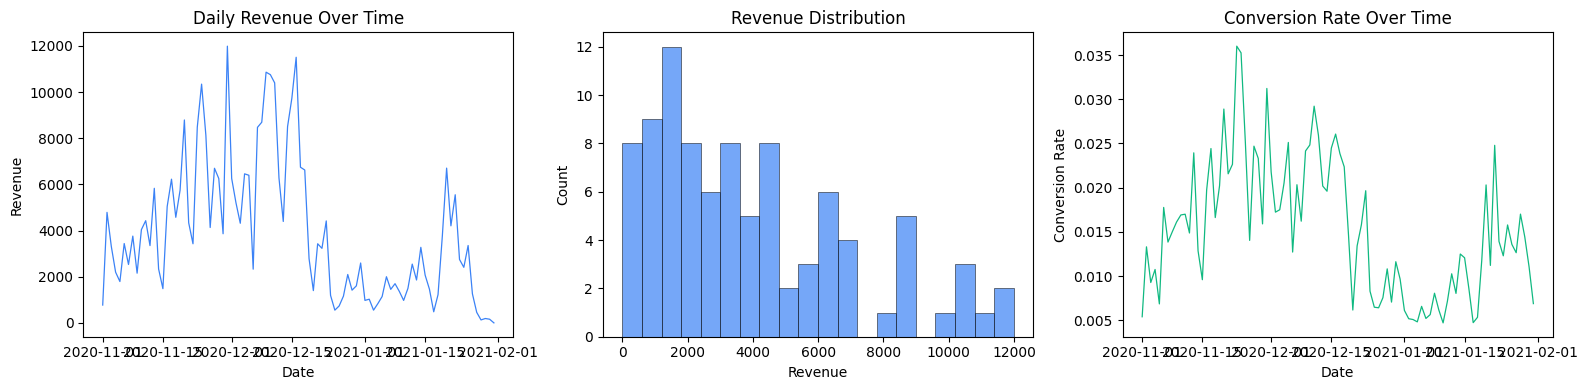

In [63]:
# Revenue distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(pd.to_datetime(df["date"]), df["revenue"], linewidth=0.9, color="#3b82f6")
axes[0].set_title("Daily Revenue Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Revenue")

axes[1].hist(df["revenue"], bins=20, edgecolor="black", linewidth=0.5, alpha=0.7, color="#3b82f6")
axes[1].set_title("Revenue Distribution")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("Count")

if "conversion_rate" in df.columns:
    axes[2].plot(pd.to_datetime(df["date"]), df["conversion_rate"], linewidth=0.9, color="#10b981")
    axes[2].set_title("Conversion Rate Over Time")
    axes[2].set_xlabel("Date")
    axes[2].set_ylabel("Conversion Rate")

plt.tight_layout()
plt.show()

## Run the Full Agentic Pipeline

**run_dataset_from_df** replays every day through the Central Controller. Each day goes through the full perception, reasoning, action, feedback cycle as described in the proposal. The system monitors revenue, detects anomalies using rolling statistics and EWMA, attributes root causes across business dimensions, ranks corrective actions by utility, and generates structured explanations.

In [64]:
result = run_dataset_from_df(df, metric_col="revenue", human_approved=False)
print(f"Processed {len(result.rows)} days through the agentic pipeline")

n_anomaly = sum(1 for r in result.rows if r.get("is_anomaly"))
n_normal = len(result.rows) - n_anomaly
print(f"Anomaly days: {n_anomaly}")
print(f"Normal days: {n_normal}")

Processed 92 days through the agentic pipeline
Anomaly days: 1
Normal days: 91


## Last Anomaly Report: Complete Decision Trace

Each detected anomaly produces a complete decision trace starting from the anomaly score and confidence, through ranked root causes with percentage attribution, to a prioritized set of corrective actions ordered by utility score. This is the full end to end output for the most recent anomaly day.

In [65]:
hit = last_anomaly_report(result.rows)
row = hit or result.rows[-1]

print(f"Date: {row.get('date')}")
print(f"Metric: {row.get('metric_name')}")
print(f"Anomaly detected: {row.get('is_anomaly')}")
print(f"Anomaly score: {row.get('anomaly_score'):.4f}")
print(f"Confidence: {row.get('confidence'):.4f}")
print(f"Execution status: {row.get('execution_status')}")
print()
if row.get("root_causes_ranked"):
    print("Root causes with contribution percentages:")
    for rc in row["root_causes_ranked"][:5]:
        print(f"  {rc['dimension']}={rc['value']}: {rc['contribution_pct']}%")
print()
if row.get("ranked_actions"):
    print("Ranked corrective actions:")
    for a in row["ranked_actions"][:5]:
        print(f"  {a['label']}, utility={a['utility']}, why: {a.get('why_ranked', '')}")
print()
print("Explanation text:")
print(row.get("explanation_text", ""))

Date: 2021-01-20T00:00:00
Metric: revenue
Anomaly detected: True
Anomaly score: 2.6881
Confidence: 0.8960
Execution status: pending_human_approval

Root causes with contribution percentages:
  product_tier=premium: 24.92%
  customer_segment=returning: 24.58%
  region=United_States: 8.87%
  channel=organic: 7.99%
  channel=referral: 6.02%

Ranked corrective actions:
  Short promotional push on underperforming channel, utility=0.5045, why: historical_recovery_impact=0.361
  Regional campaign adjustment, utility=0.4488, why: historical_recovery_impact=0.361
  Retargeting / remarketing to high intent segments, utility=0.4159, why: historical_recovery_impact=0.361
  Refresh creatives / landing pages for underperforming traffic, utility=0.4017, why: historical_recovery_impact=0.361
  Shopping feed and search listing hygiene for titles, GTIN, negatives, utility=0.3816, why: historical_recovery_impact=0.361

Explanation text:
Revenue on Jan 20, 2021: value 6,706.00, baseline 2,168.64, spread 1

## Dashboard: Revenue Trend with Rolling Baseline and Anomaly Markers

Revenue time series overlaid with the 14 day rolling mean and plus/minus one standard deviation band. Red markers indicate days the agentic system flagged as anomalies. This replicates the main chart from the Streamlit dashboard.

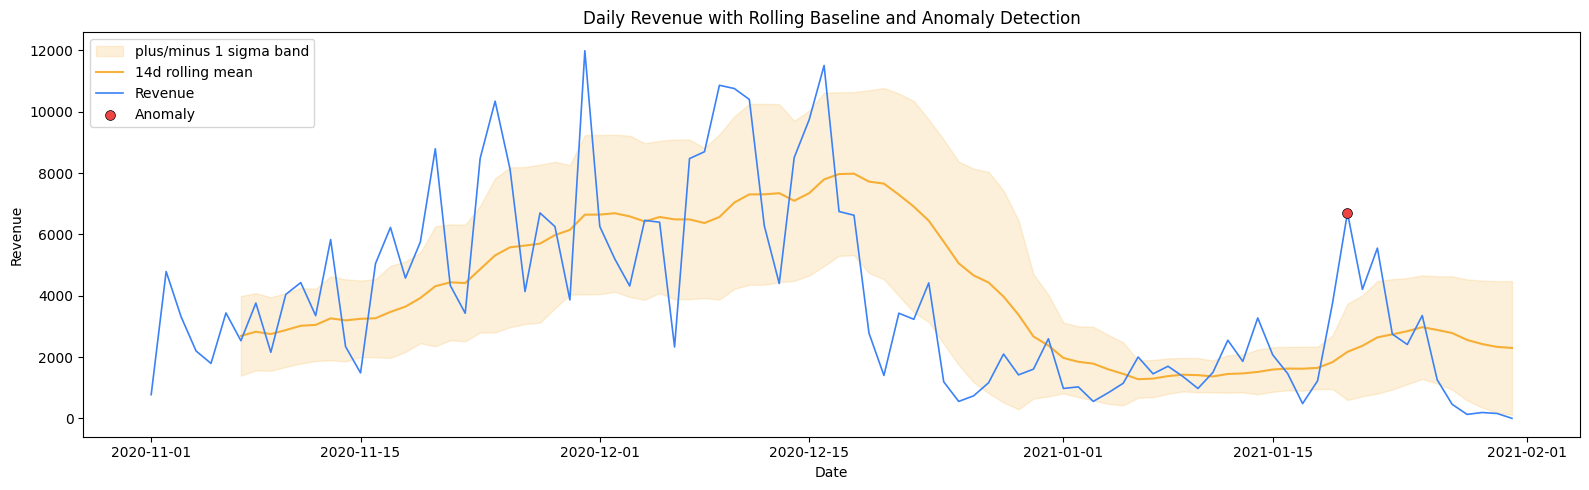

In [66]:
dates_plot = pd.to_datetime([r["date"] for r in result.rows])
values = np.array([r["current_value"] for r in result.rows])
anomalies = [r["is_anomaly"] for r in result.rows]

# Compute rolling stats for the band
rev_series = pd.Series(values)
rolling_mean = rev_series.rolling(14, min_periods=7).mean()
rolling_std = rev_series.rolling(14, min_periods=7).std()
upper_band = rolling_mean + rolling_std
lower_band = rolling_mean - rolling_std

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(dates_plot, lower_band, upper_band, alpha=0.15, color="#f59e0b", label="plus/minus 1 sigma band")
ax.plot(dates_plot, rolling_mean, linewidth=1.5, color="#f59e0b", alpha=0.8, label="14d rolling mean")
ax.plot(dates_plot, values, linewidth=1.2, color="#3b82f6", label="Revenue")
anom_dates = [d for d, a in zip(dates_plot, anomalies) if a]
anom_vals = [v for v, a in zip(values, anomalies) if a]
ax.scatter(anom_dates, anom_vals, color="#ef4444", zorder=5, label="Anomaly", s=50, edgecolors="black", linewidths=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.set_title("Daily Revenue with Rolling Baseline and Anomaly Detection")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Dashboard: Anomaly Score and Confidence Over Time

Top panel shows the blended anomaly score for every day with the z threshold marked as a horizontal line. Days above the threshold are flagged. Bottom panel shows detection confidence with the minimum confidence floor marked. Days below the floor are stopped from progressing to root cause analysis.

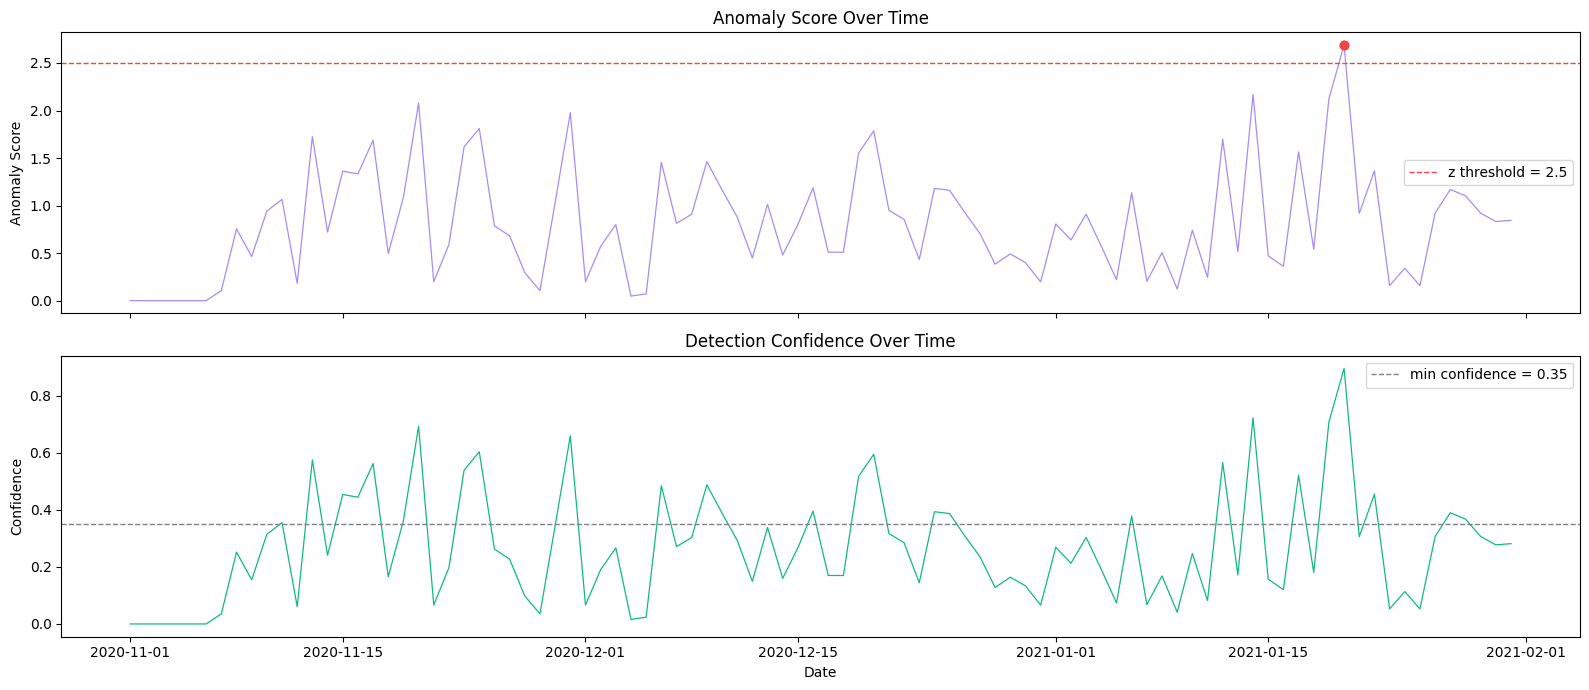

In [67]:
scores = [r.get("anomaly_score") or 0.0 for r in result.rows]
confidences = [r.get("confidence") or 0.0 for r in result.rows]

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# Anomaly score
axes[0].plot(dates_plot, scores, linewidth=0.9, color="#a78bfa")
axes[0].axhline(DetectionConfig().z_threshold, color="#ef4444", linestyle="--", linewidth=1.0, label=f"z threshold = {DetectionConfig().z_threshold}")
anom_scores = [s for s, a in zip(scores, anomalies) if a]
anom_d = [d for d, a in zip(dates_plot, anomalies) if a]
if anom_d:
    axes[0].scatter(anom_d, anom_scores, color="#ef4444", zorder=5, s=40)
axes[0].set_ylabel("Anomaly Score")
axes[0].set_title("Anomaly Score Over Time")
axes[0].legend()

# Confidence
axes[1].plot(dates_plot, confidences, linewidth=0.9, color="#10b981")
axes[1].axhline(DetectionConfig().min_confidence, color="gray", linestyle="--", linewidth=1.0, label=f"min confidence = {DetectionConfig().min_confidence}")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Confidence")
axes[1].set_title("Detection Confidence Over Time")
axes[1].legend()

plt.tight_layout()
plt.show()

## Dashboard: Root Cause Contribution for Last Anomaly Day

Horizontal bar chart showing each business dimension contribution percentage for the most recent anomaly. The Root Cause Agent computes these by measuring each dimension deviation from its rolling baseline relative to the total deviation. No causal inference modeling is applied, attribution is entirely from observed metric differences.

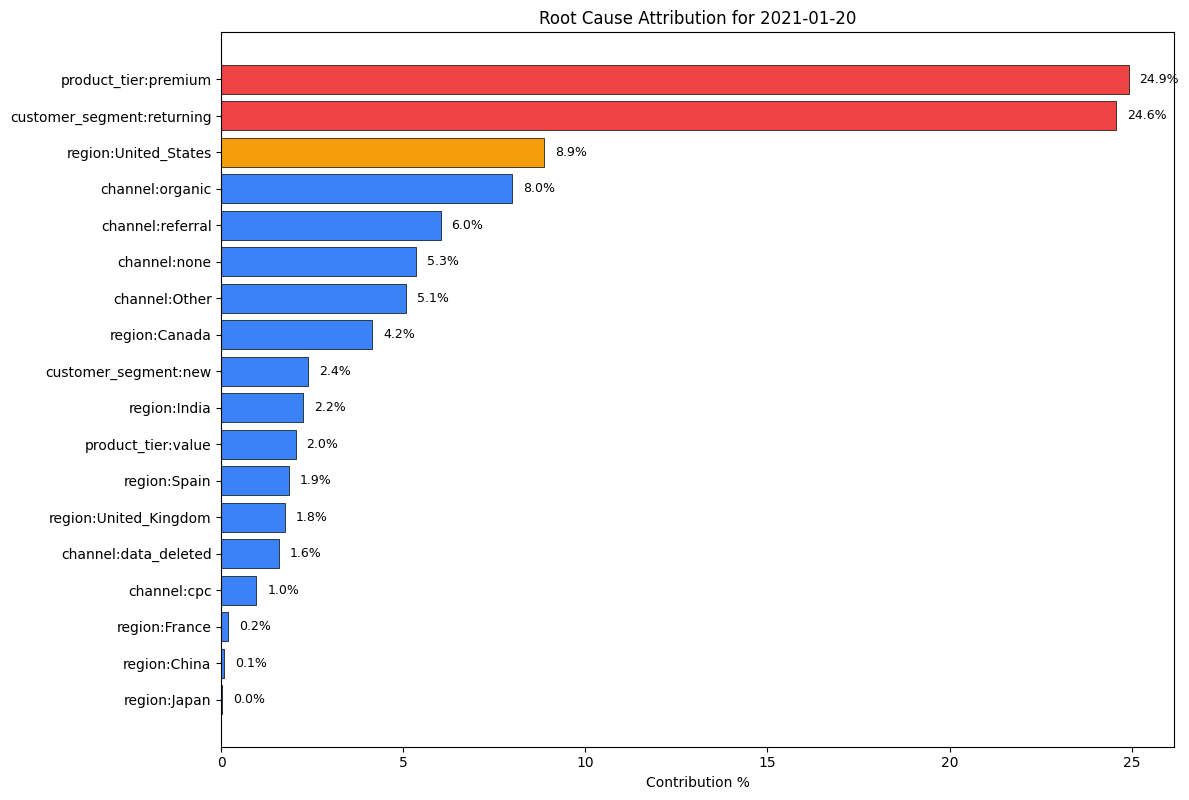

In [68]:
rc_data = row.get("root_causes_ranked", [])
if rc_data:
    labels = [f"{r['dimension']}:{r['value']}" for r in rc_data]
    pcts = [r["contribution_pct"] for r in rc_data]
    colors = ["#ef4444" if p > 15 else "#f59e0b" if p > 8 else "#3b82f6" for p in pcts]

    fig, ax = plt.subplots(figsize=(12, max(4, len(labels) * 0.45)))
    bars = ax.barh(labels[::-1], pcts[::-1], color=colors[::-1], edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Contribution %")
    ax.set_title(f"Root Cause Attribution for {row.get('date', '')[:10]}")
    for bar, val in zip(bars, pcts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No root causes found for the last anomaly day")

## Dashboard: Ranked Corrective Actions by Utility Score

The Decision Agent evaluates each predefined corrective action using a utility function that combines expected impact, risk variance, operational cost, context boost from root cause attribution, and historical recovery impact. Actions are shown ranked by total utility score.

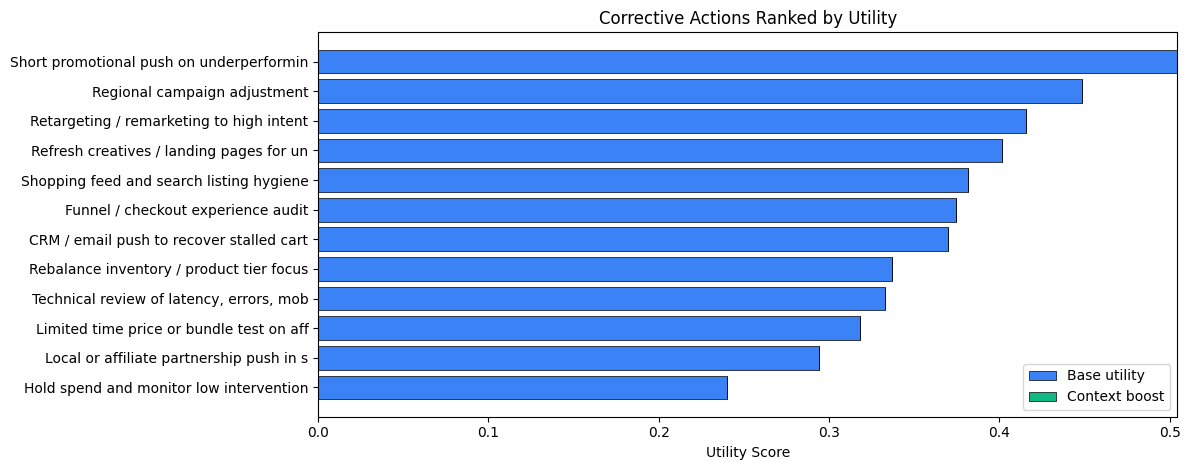

In [69]:
acts = row.get("ranked_actions", [])
if acts:
    act_labels = [a["label"][:45] for a in acts]
    act_utils = [a["utility"] for a in acts]
    act_base = [a.get("utility_base", 0) for a in acts]
    act_boost = [a.get("context_boost", 0) for a in acts]

    fig, ax = plt.subplots(figsize=(12, max(4, len(acts) * 0.4)))
    y_pos = range(len(acts))

    bars_base = ax.barh([act_labels[i][:40] for i in range(len(acts)-1, -1, -1)],
                        [act_base[i] for i in range(len(acts)-1, -1, -1)],
                        color="#3b82f6", edgecolor="black", linewidth=0.5, label="Base utility")
    bars_boost = ax.barh([act_labels[i][:40] for i in range(len(acts)-1, -1, -1)],
                         [act_boost[i] for i in range(len(acts)-1, -1, -1)],
                         left=[act_base[i] for i in range(len(acts)-1, -1, -1)],
                         color="#10b981", edgecolor="black", linewidth=0.5, label="Context boost")

    ax.set_xlabel("Utility Score")
    ax.set_title("Corrective Actions Ranked by Utility")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("No ranked actions available")

## Sensitivity Comparison Across Detection Thresholds

The same CSV is run at four detection thresholds: standard, balanced, sensitive, and explorer. Lower z threshold surfaces more anomaly days from the same real data with no synthetic injection. This demonstrates that the system adapts to different operational sensitivity requirements.

standard      z_thr=2.50  min_conf=0.35  anomaly_days=1/92
balanced      z_thr=2.00  min_conf=0.28  anomaly_days=4/92
sensitive     z_thr=1.70  min_conf=0.22  anomaly_days=8/92
explorer      z_thr=1.45  min_conf=0.18  anomaly_days=15/92


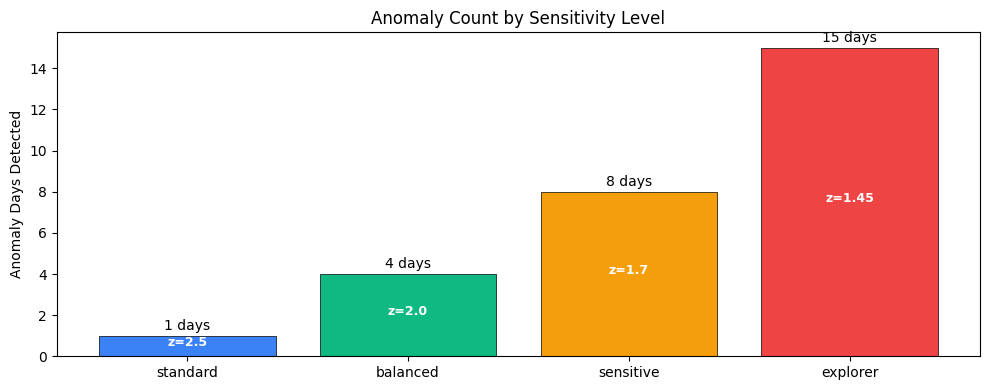

In [70]:
sens_results = {}
for name in ("standard", "balanced", "sensitive", "explorer"):
    det = detection_sensitivity(name)
    res = run_dataset_from_df(df, metric_col="revenue", detection=det)
    n_anom = sum(1 for r in res.rows if r.get("is_anomaly"))
    sens_results[name] = {"z_thr": det.z_threshold, "min_conf": det.min_confidence, "anomalies": n_anom, "total": len(res.rows)}
    print(f"{name:12s}  z_thr={det.z_threshold:.2f}  min_conf={det.min_confidence:.2f}  anomaly_days={n_anom}/{len(res.rows)}")

fig, ax = plt.subplots(figsize=(10, 4))
names = list(sens_results.keys())
anoms = [sens_results[n]["anomalies"] for n in names]
thrs = [sens_results[n]["z_thr"] for n in names]
bars = ax.bar(names, anoms, color=["#3b82f6", "#10b981", "#f59e0b", "#ef4444"], edgecolor="black", linewidth=0.5)
for bar, val, thr in zip(bars, anoms, thrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val} days", ha="center", fontsize=10)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f"z={thr}", ha="center", fontsize=9, color="white", fontweight="bold")
ax.set_ylabel("Anomaly Days Detected")
ax.set_title("Anomaly Count by Sensitivity Level")
plt.tight_layout()
plt.show()

## Evaluation: Single Seed Inject Mode

Controlled anomaly injection with 10 synthetic revenue spikes at known timestamps and known root cause dimensions. The agentic system is compared against three non agentic baselines on detection F1, root cause accuracy, utility, and ranking consistency. This follows the evaluation framework defined in the proposal.

In [71]:
report = run_evaluation(df, mode="inject", inject_events=10, seed=42, metric_col="revenue")

table = evaluation_table(report)
print("Detection and RCA Comparison Table")
print(table.to_string(index=False))
print()
print(f"Root cause top 1 accuracy: {report['root_cause']['top1']['accuracy']:.2f}")
print(f"Root cause top 3 accuracy: {report['root_cause']['top3']['accuracy']:.2f}")
print(f"Mean top 1 utility: {report['decision']['mean_top1_utility']['mean_top1_utility']:.4f}")
print(f"Utility gain vs random: {report['decision']['utility_vs_random_action_mean']['gain']:.4f}")
print(f"Ranking consistency Kendall tau: {report['decision']['ranking_consistency_vs_impact_order']['kendall_tau']:.4f}")
print(f"End to end latency: {report['system']['end_to_end_total_ms']:.1f} ms")
print(f"Confidence on true anomaly days: {report['system']['confidence_proxy']['mean_confidence_on_true_anomaly_days']:.4f}")

Detection and RCA Comparison Table
                     system  precision  recall       f1
             agentic_system   1.000000     0.1 0.181818
baseline_1_static_threshold   0.172414     0.5 0.256410
          baseline_2_z_only   0.000000     0.0 0.000000
   baseline_3_manual_script   0.089744     0.7 0.159091
            root_cause_top1        NaN     NaN 0.100000
            root_cause_top3        NaN     NaN 0.100000
  decision_rank_consistency        NaN     NaN 0.666667

Root cause top 1 accuracy: 0.10
Root cause top 3 accuracy: 0.10
Mean top 1 utility: 0.7227
Utility gain vs random: 0.2969
Ranking consistency Kendall tau: 0.6667
End to end latency: 1245.6 ms
Confidence on true anomaly days: 0.4478


## Dashboard: Detection F1 Comparison Across All Systems

Grouped bar chart comparing precision, recall, and F1 score for the agentic system against all three non agentic baselines. This directly addresses the proposal evaluation requirement of comparing against a static threshold system, a z only detector, and a manual script baseline.

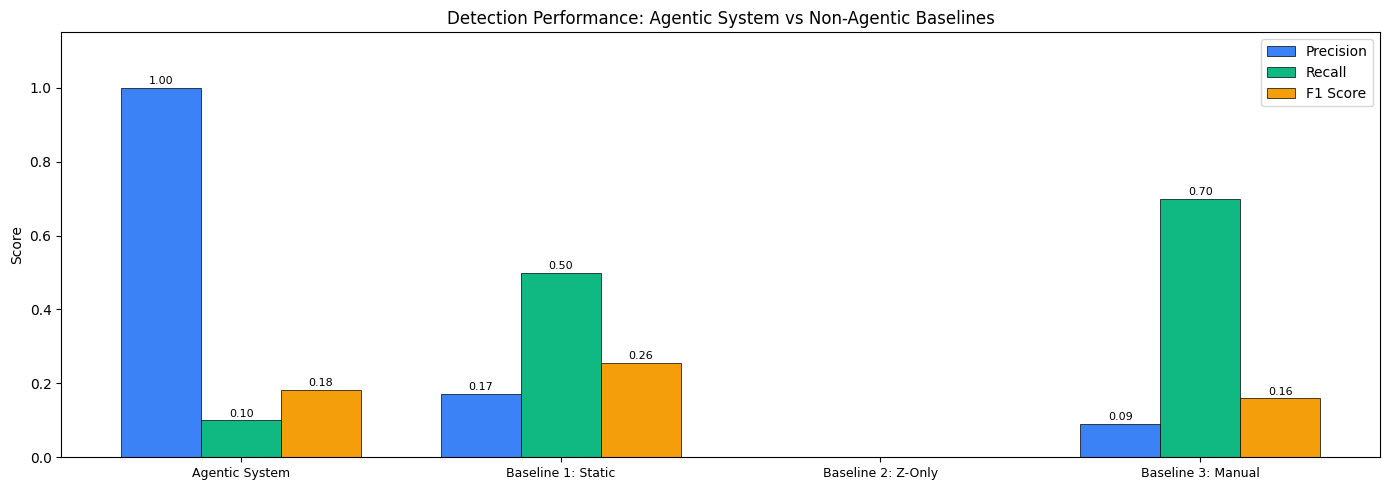

In [72]:
det = report["detection"]
systems = list(det.keys())
display_names = ["Agentic System", "Baseline 1: Static", "Baseline 2: Z-Only", "Baseline 3: Manual"]

prec_vals = [det[s]["precision"] for s in systems]
rec_vals = [det[s]["recall"] for s in systems]
f1_vals = [det[s]["f1"] for s in systems]

x = np.arange(len(display_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width, prec_vals, width, label="Precision", color="#3b82f6", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x, rec_vals, width, label="Recall", color="#10b981", edgecolor="black", linewidth=0.5)
bars3 = ax.bar(x + width, f1_vals, width, label="F1 Score", color="#f59e0b", edgecolor="black", linewidth=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha="center", fontsize=8)

ax.set_ylabel("Score")
ax.set_title("Detection Performance: Agentic System vs Non-Agentic Baselines")
ax.set_xticks(x)
ax.set_xticklabels(display_names, fontsize=9)
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

## Dashboard: Decision Utility Comparison

The agentic system mean top 1 utility versus the random action selection baseline. This measures the value added by the utility based decision ranking compared to choosing actions without any ranking logic.

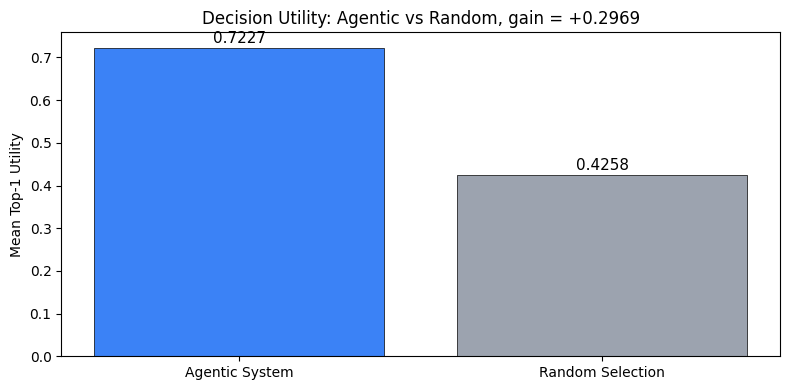

In [73]:
agent_u = report["decision"]["utility_vs_random_action_mean"]["agent_mean_utility"]
random_u = report["decision"]["utility_vs_random_action_mean"]["baseline_mean_utility"]
gain = report["decision"]["utility_vs_random_action_mean"]["gain"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(["Agentic System", "Random Selection"], [agent_u, random_u],
              color=["#3b82f6", "#9ca3af"], edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, [agent_u, random_u]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.4f}", ha="center", fontsize=11)
ax.set_ylabel("Mean Top-1 Utility")
ax.set_title(f"Decision Utility: Agentic vs Random, gain = {gain:+.4f}")
plt.tight_layout()
plt.show()

## Controller Re Evaluation Smoke Test

The Central Controller triggers re evaluation when it detects conflict patterns such as an anomaly flagged with near threshold confidence alongside empty root causes but non empty ranked actions. This test artificially introduces that conflict and verifies the controller fires a second pass with a stricter anomaly threshold.

In [74]:
reeval = conflict_reeval_smoke_test(df, metric_col="revenue")
print(f"Re evaluation smoke test passed: {reeval['ok']}")
print(f"  reeval_round before: {reeval.get('reeval_round_before')}")
print(f"  reeval_round after:  {reeval.get('reeval_round_after')}")

Re evaluation smoke test passed: True
  reeval_round before: 0
  reeval_round after:  1


## Multi Seed Evaluation with Paired Statistical Tests

Inject mode evaluation is repeated across 5 independent RNG seeds with different injection placements each time. This tests reproducibility and stability as required by the proposal. Paired t test and Wilcoxon signed rank test compare agent F1 versus each baseline F1.

In [75]:
seeds = [42, 43, 44, 45, 46]
multi = run_multi_seed_study(df, seeds=seeds, inject_events=10, metric_col="revenue")

print("Summary: mean +/- stdev, min to max")
for key in ("agentic_f1", "baseline_1_f1", "baseline_2_f1", "baseline_3_f1", "root_cause_top1_accuracy", "root_cause_top3_accuracy"):
    s = multi["summary"][key]
    print(f"  {key:35s}  {s['mean']:.4f} +/- {s['stdev']:.4f}  [{s['min']:.4f}, {s['max']:.4f}]")

print()
print("Paired Tests for F1: agentic vs baselines")
for pt in multi["paired_tests_f1"]:
    print(f"  {pt['comparison']:45s}  t={pt['paired_t_statistic']:+.3f}  p={pt['paired_t_pvalue']:.4f}  delta={pt['mean_delta']:+.4f}")

Summary: mean +/- stdev, min to max
  agentic_f1                           0.1979 +/- 0.1330  [0.0000, 0.3333]
  baseline_1_f1                        0.2563 +/- 0.0592  [0.1538, 0.2927]
  baseline_2_f1                        0.1394 +/- 0.1415  [0.0000, 0.3333]
  baseline_3_f1                        0.1786 +/- 0.0276  [0.1556, 0.2247]
  root_cause_top1_accuracy             0.0600 +/- 0.0894  [0.0000, 0.2000]
  root_cause_top3_accuracy             0.0800 +/- 0.0837  [0.0000, 0.2000]

Paired Tests for F1: agentic vs baselines
  agentic_vs_baseline_1_static_threshold         t=-1.553  p=0.1954  delta=-0.0584
  agentic_vs_baseline_2_z_only                   t=+1.312  p=0.2598  delta=+0.0585
  agentic_vs_baseline_3_manual_script            t=+0.276  p=0.7961  delta=+0.0193


## Dashboard: Per Seed F1 Comparison

F1 scores for the agentic system and all baselines across each seed. This visualizes the stability of detection performance across independent injection placements.

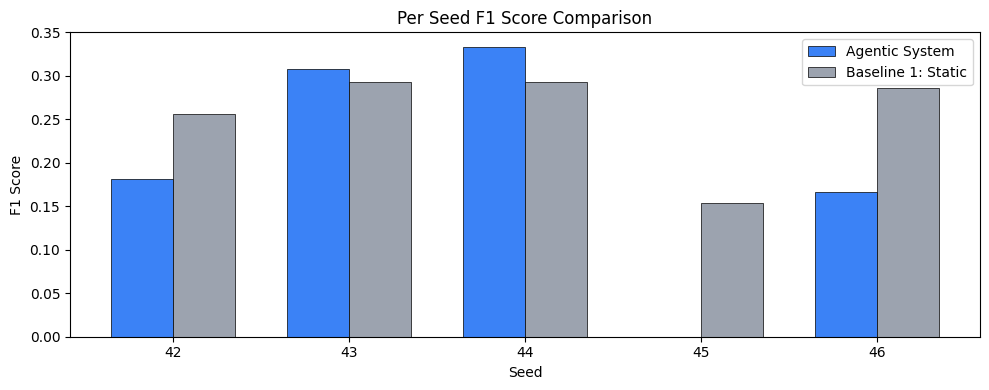


Per Seed Results Table
 seed  agent_f1  baseline_1_f1  rc_top1
   42  0.181818       0.256410      0.1
   43  0.307692       0.292683      0.0
   44  0.333333       0.292683      0.2
   45  0.000000       0.153846      0.0
   46  0.166667       0.285714      0.0


In [76]:
per_seed_data = multi["per_seed"]
seed_labels = [str(p["seed"]) for p in per_seed_data]
agent_f1s = [p["agent_f1"] for p in per_seed_data]
b1_f1s = [p["baseline_1_f1"] for p in per_seed_data]

x = np.arange(len(seed_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, agent_f1s, width, label="Agentic System", color="#3b82f6", edgecolor="black", linewidth=0.5)
ax.bar(x + width/2, b1_f1s, width, label="Baseline 1: Static", color="#9ca3af", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Seed")
ax.set_ylabel("F1 Score")
ax.set_title("Per Seed F1 Score Comparison")
ax.set_xticks(x)
ax.set_xticklabels(seed_labels)
ax.legend()
plt.tight_layout()
plt.show()

print()
print("Per Seed Results Table")
print(pd.DataFrame(per_seed_data).to_string(index=False))

## Advanced Evaluation with Paired T Test

Three inject mode evaluations with paired t test comparing agent F1 versus baseline 2 z only F1. Also reports Cohen kappa for explanation quality if human rater label columns are present.

In [77]:
adv = run_advanced_evaluation(df, metric_col="revenue", runs=3, base_seed=42)

print(f"Runs: {adv['runs']}, Seeds: {adv['seeds']}")
print(f"Agent F1 per run: {[round(f, 4) for f in adv['agent_f1']]}")
print(f"Baseline 2 F1 per run: {[round(f, 4) for f in adv['baseline2_f1']]}")
print(f"Paired t test: t={adv['paired_t_test_agent_vs_baseline2']['t_stat']:.3f}, p={adv['paired_t_test_agent_vs_baseline2']['p_value']:.4f}")
print(f"Cohen kappa for explanation: {adv['cohens_kappa_explanation']}")

Runs: 3, Seeds: [42, 43, 44]
Agent F1 per run: [0.1818, 0.3077, 0.3333]
Baseline 2 F1 per run: [0.0, 0.3333, 0.1818]
Paired t test: t=1.585, p=0.2538
Cohen kappa for explanation: None


## Fit Learned Action Boosts

Per action utility adjustments are learned from 8 inject mode runs. This is the closest component to model training in this system. It uses injection ground truth dimension keys as supervision to reward actions that align with the detected root cause dimension. The output is saved to JSON so it does not need to be re computed.

Learned boosts per action:
  promo_surge                +0.0510
  geo_campaign               +0.0180
  inventory_rebalance        +0.0090
  creative_refresh           +0.0030
Scored anomaly days: 13
Saved to learned_action_boosts.json


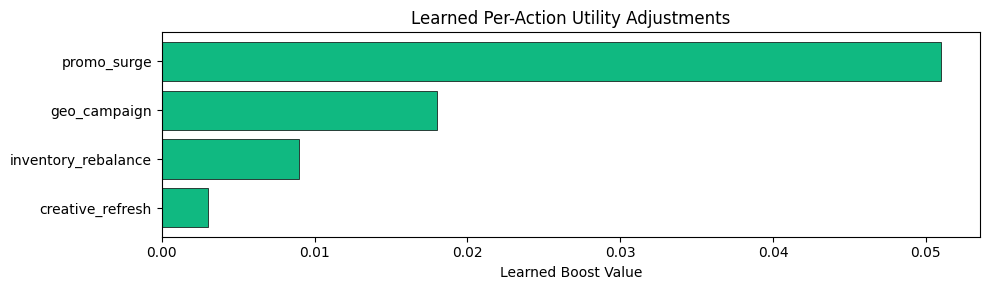

In [78]:
learned = fit_learned_boosts(df, seeds=[42 + i for i in range(8)], inject_events=10, metric_col="revenue")

print("Learned boosts per action:")
for aid, b in sorted(learned["learned_boosts"].items(), key=lambda x: -x[1]):
    print(f"  {aid:25s}  {b:+.4f}")
print(f"Scored anomaly days: {learned['meta']['scored_anomaly_days']}")

with open("learned_action_boosts.json", "w") as f:
    json.dump(learned, f, indent=2)
print("Saved to learned_action_boosts.json")

# Visualize the learned boosts
if learned["learned_boosts"]:
    sorted_boosts = sorted(learned["learned_boosts"].items(), key=lambda x: x[1], reverse=True)
    boost_names = [b[0] for b in sorted_boosts]
    boost_vals = [b[1] for b in sorted_boosts]
    colors = ["#10b981" if v > 0 else "#ef4444" for v in boost_vals]

    fig, ax = plt.subplots(figsize=(10, max(3, len(boost_names) * 0.4)))
    ax.barh(boost_names[::-1], boost_vals[::-1], color=colors[::-1], edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("Learned Boost Value")
    ax.set_title("Learned Per-Action Utility Adjustments")
    plt.tight_layout()
    plt.show()

## Dashboard: Anomaly Score Distribution

Histogram of anomaly scores across all days. The vertical dashed line marks the z threshold. Days to the right are flagged as anomalies. The distribution shape indicates how well separated normal days are from anomalous ones.

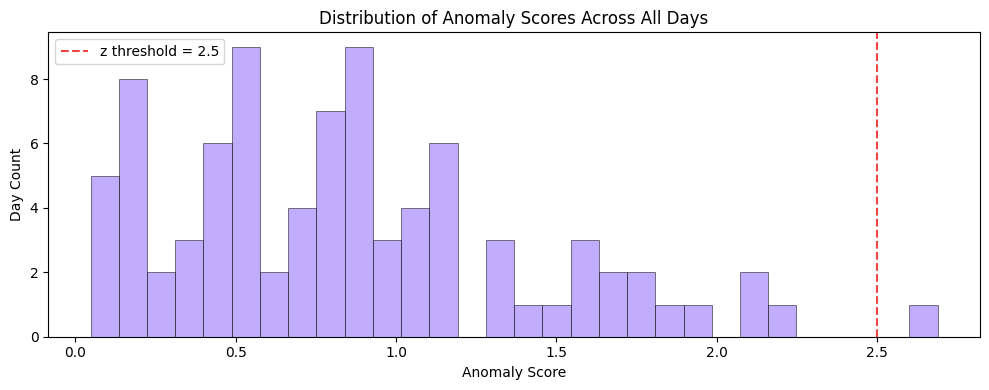

In [79]:
all_scores = [r.get("anomaly_score") or 0.0 for r in result.rows if r.get("anomaly_score") is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_scores, bins=30, edgecolor="black", linewidth=0.5, alpha=0.7, color="#a78bfa")
ax.axvline(DetectionConfig().z_threshold, color="#ef4444", linestyle="--", linewidth=1.5, label=f"z threshold = {DetectionConfig().z_threshold}")
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Day Count")
ax.set_title("Distribution of Anomaly Scores Across All Days")
ax.legend()
plt.tight_layout()
plt.show()

## System Architecture Diagram

Visual representation of the agentic multi agent architecture with Shared Memory and Controller based coordination as described in the proposal. All agents read from and write to Shared Memory. The Central Controller governs stage transitions and triggers re evaluation when conflicts are detected.

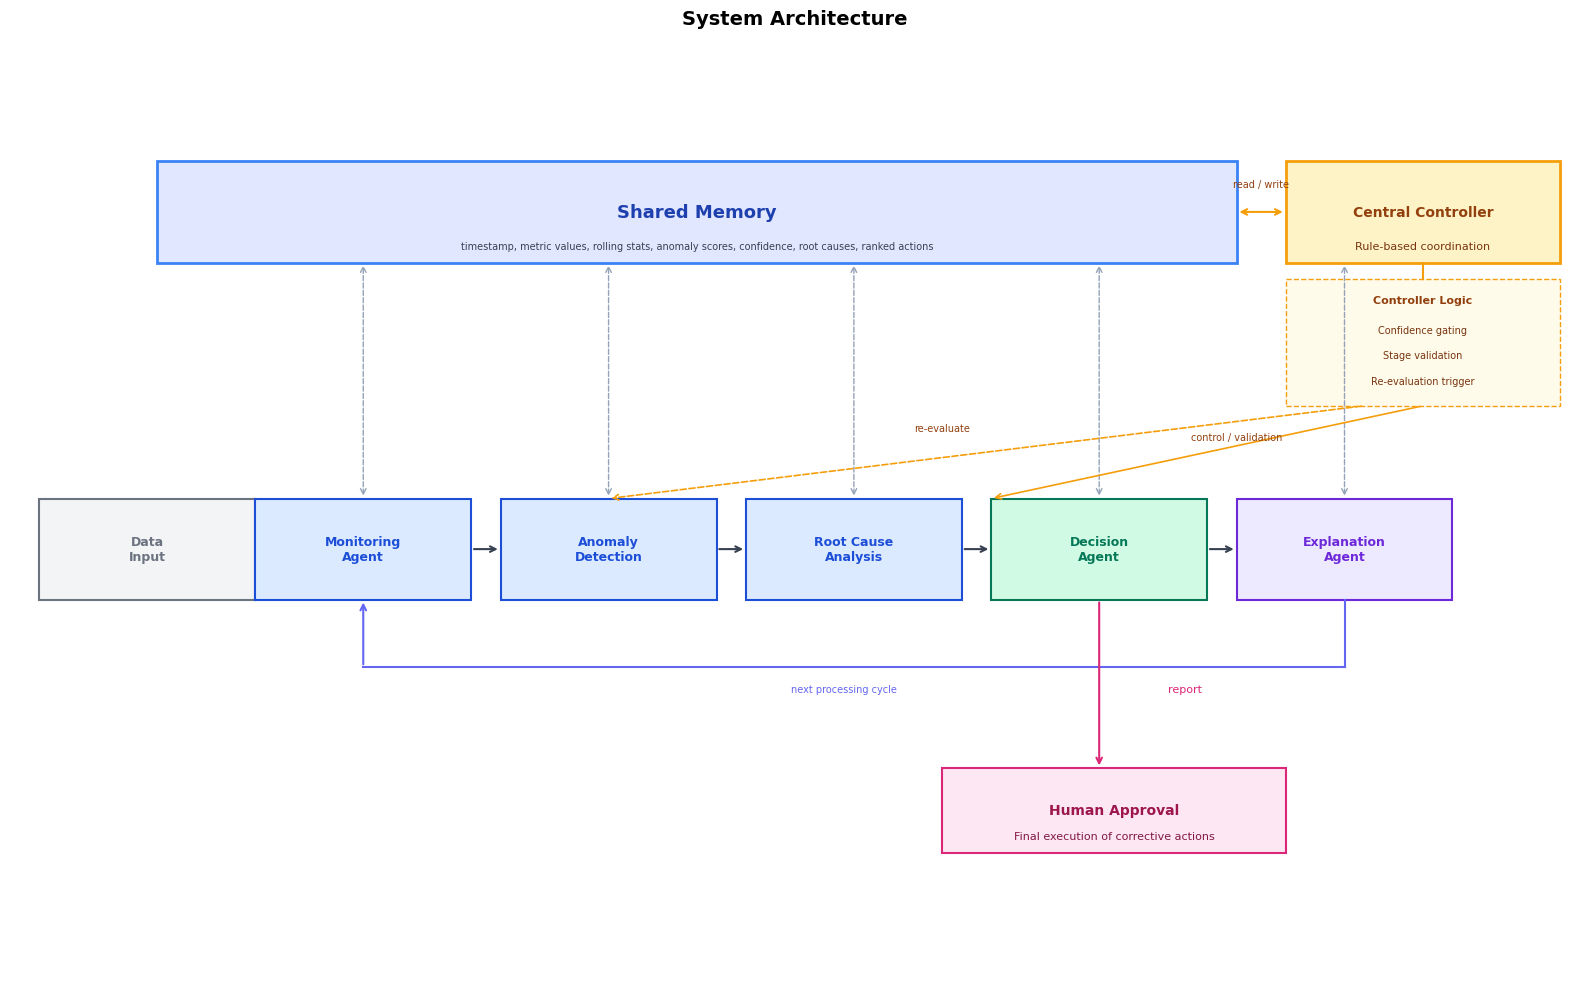

In [80]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 11)
ax.axis("off")

ax.set_title("System Architecture", fontsize=14, fontweight="bold", pad=20)

# Shared Memory
ax.add_patch(plt.Rectangle((1.5, 8.5), 11, 1.2,
             facecolor="#e0e7ff", edgecolor="#3b82f6", linewidth=2))
ax.text(7, 9.1, "Shared Memory", ha="center", va="center",
        fontsize=13, fontweight="bold", color="#1e40af")
ax.text(7, 8.7,
        "timestamp, metric values, rolling stats, anomaly scores, confidence, root causes, ranked actions",
        ha="center", va="center", fontsize=7, color="#374151")

# Central Controller
ax.add_patch(plt.Rectangle((13, 8.5), 2.8, 1.2,
             facecolor="#fef3c7", edgecolor="#f59e0b", linewidth=2))
ax.text(14.4, 9.1, "Central Controller", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#92400e")
ax.text(14.4, 8.7, "Rule-based coordination", ha="center", va="center",
        fontsize=8, color="#78350f")

# Controller detail box
ax.add_patch(plt.Rectangle((13, 6.8), 2.8, 1.5,
             facecolor="#fffbeb", edgecolor="#f59e0b", linewidth=1, linestyle="dashed"))
ax.text(14.4, 8.05, "Controller Logic", ha="center", va="center",
        fontsize=8, fontweight="bold", color="#92400e")
ax.text(14.4, 7.7, "Confidence gating", ha="center", va="center",
        fontsize=7, color="#78350f")
ax.text(14.4, 7.4, "Stage validation", ha="center", va="center",
        fontsize=7, color="#78350f")
ax.text(14.4, 7.1, "Re-evaluation trigger", ha="center", va="center",
        fontsize=7, color="#78350f")

# Controller box to detail box connection
ax.plot([14.4, 14.4], [8.5, 8.3], color="#f59e0b", lw=1.5)

# Shared Memory <-> Controller
ax.annotate("", xy=(12.5, 9.1), xytext=(13, 9.1),
            arrowprops=dict(arrowstyle="<->", color="#f59e0b", lw=1.5))
ax.text(12.75, 9.4, "read / write", fontsize=7, color="#92400e", ha="center")

# Agents
agents = [
    (0.3, 4.5, "Data\nInput", "#f3f4f6", "#6b7280"),
    (2.5, 4.5, "Monitoring\nAgent", "#dbeafe", "#1d4ed8"),
    (5.0, 4.5, "Anomaly\nDetection", "#dbeafe", "#1d4ed8"),
    (7.5, 4.5, "Root Cause\nAnalysis", "#dbeafe", "#1d4ed8"),
    (10.0, 4.5, "Decision\nAgent", "#d1fae5", "#047857"),
    (12.5, 4.5, "Explanation\nAgent", "#ede9fe", "#6d28d9"),
]

for x, y, label, fc, ec in agents:
    ax.add_patch(plt.Rectangle((x, y), 2.2, 1.2,
                 facecolor=fc, edgecolor=ec, linewidth=1.5))
    ax.text(x + 1.1, y + 0.6, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color=ec)

# Pipeline arrows between agents
for i in range(len(agents) - 1):
    x1 = agents[i][0] + 2.2
    x2 = agents[i + 1][0]
    ax.annotate("", xy=(x2, 5.1), xytext=(x1, 5.1),
                arrowprops=dict(arrowstyle="->", color="#374151", lw=1.5))

# Dashed lines from each agent up to Shared Memory
for x, y, _, _, _ in agents[1:]:
    ax.annotate("", xy=(x + 1.1, 8.5), xytext=(x + 1.1, y + 1.2),
                arrowprops=dict(arrowstyle="<->", color="#94a3b8",
                                lw=1, linestyle="dashed"))

# Control arrow from Controller detail to pipeline
ax.annotate("", xy=(10.0, 5.7), xytext=(14.4, 6.8),
            arrowprops=dict(arrowstyle="->", color="#f59e0b", lw=1.2))
ax.text(12.5, 6.4, "control / validation",
        fontsize=7, color="#92400e", ha="center")

# Re-evaluate dashed arrow from Controller to Anomaly Detection
ax.annotate("", xy=(6.1, 5.7), xytext=(13.8, 6.8),
            arrowprops=dict(arrowstyle="->", color="#f59e0b",
                            lw=1.2, linestyle="dashed"))
ax.text(9.5, 6.5, "re-evaluate", fontsize=7, color="#92400e", ha="center")

# Next processing cycle
ex_x = 13.6
mon_x = 3.6
box_bottom = 4.5
drop_y = 3.7

ax.plot([ex_x, ex_x], [box_bottom, drop_y], color="#6366f1", lw=1.5)
ax.plot([ex_x, mon_x], [drop_y, drop_y], color="#6366f1", lw=1.5)
ax.annotate("", xy=(mon_x, box_bottom), xytext=(mon_x, drop_y),
            arrowprops=dict(arrowstyle="->", color="#6366f1", lw=1.5))
ax.text(8.5, 3.4, "next processing cycle",
        fontsize=7, color="#6366f1", ha="center")

# Human Approval
ax.add_patch(plt.Rectangle((9.5, 1.5), 3.5, 1,
             facecolor="#fce7f3", edgecolor="#db2777", linewidth=1.5))
ax.text(11.25, 2.0, "Human Approval", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#9d174d")
ax.text(11.25, 1.7, "Final execution of corrective actions",
        ha="center", va="center", fontsize=8, color="#831843")

# Decision Agent to Human Approval
ax.annotate("", xy=(11.1, 2.5), xytext=(11.1, 4.5),
            arrowprops=dict(arrowstyle="->", color="#db2777", lw=1.5))
ax.text(11.8, 3.4, "report", fontsize=8, color="#db2777", ha="left")

plt.tight_layout()
plt.show()

## Interactive Dashboard

**Full interactive dashboard** rendered directly inside the notebook using Plotly.js. Has 4 tabs matching the web_edi Django application: Overview with KPIs and revenue trend, Charts with anomaly scores and confidence, Evaluation with F1 comparison and paired tests, and Insights with root cause attribution and ranked actions. Also saves as edi_dashboard.html for full screen viewing in a browser.

In [81]:
import os, zipfile, shutil
from google.colab import files

print("Upload Enterprise-Decision-Intelligence-main.zip")
uploaded_zip = files.upload()
zip_name = list(uploaded_zip.keys())[0]

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

!cp -r Enterprise-Decision-Intelligence-main/* .

os.makedirs("data", exist_ok=True)
if not os.path.exists("data/ga4_public_daily.csv"):
    shutil.copy(CSV_PATH, "data/ga4_public_daily.csv")

for f in ["dashboard/app.py", "data/ga4_public_daily.csv", "web_edi/manage.py"]:
    status = "found" if os.path.exists(f) else "MISSING"
    print(f"  {f}: {status}")

print("Project extracted successfully")

Upload Enterprise-Decision-Intelligence-main.zip


Saving Enterprise-Decision-Intelligence-main.zip to Enterprise-Decision-Intelligence-main (1).zip
  dashboard/app.py: found
  data/ga4_public_daily.csv: found
  web_edi/manage.py: found
Project extracted successfully


In [83]:
import os, subprocess, sys, time

# clone, chdir to web_edi, pip install, migrate

!pkill -f "manage.py runserver" 2>/dev/null
time.sleep(2)

# 0.0.0.0 so Colab’s tunnel can reach the process
proc = subprocess.Popen(
    [sys.executable, "manage.py", "runserver", "0.0.0.0:8000", "--noreload"],
    cwd=os.getcwd(),
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)

print("Waiting for Django to boot")
time.sleep(10)

# Read stderr in case Django crashed for debug
# err = proc.stderr.read().decode(); print(err[:2000] if err else "no stderr")

from google.colab import output
output.serve_kernel_port_as_iframe(8000)

^C
Waiting for Django to boot


<IPython.core.display.Javascript object>

In [84]:
import os
os.environ["DJANGO_ALLOWED_HOSTS"] = "*"

In [85]:
import os, subprocess, sys, time
import urllib.error
import urllib.request
from pathlib import Path

# So Django settings apply Colab rules even if runserver subprocess misses COLAB_RELEASE_TAG
try:
    import google.colab  # noqa: F401
    os.environ["DJANGO_IN_COLAB"] = "1"
except ImportError:
    pass

def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "web_edi" / "manage.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Could not find web_edi/manage.py — clone/upload the repo or open the notebook from the repo root."
    )

root = _repo_root()
os.chdir(root)
req = root / "requirements_django.txt"
if req.is_file():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)])
else:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "django>=4.2,<6"])

web_edi = root / "web_edi"

if sys.platform != "win32":
    os.system("pkill -f 'manage.py runserver' 2>/dev/null")
time.sleep(2)

subprocess.run(
    [sys.executable, "manage.py", "migrate", "--noinput"],
    cwd=str(web_edi),
    check=True,
)

_env = os.environ.copy()
_env.setdefault("DJANGO_IN_COLAB", os.environ.get("DJANGO_IN_COLAB", "0"))

kwargs = {
    "cwd": str(web_edi),
    "stdout": subprocess.DEVNULL,
    "stderr": subprocess.DEVNULL,
    "env": _env,
}
if sys.platform != "win32":
    kwargs["start_new_session"] = True
subprocess.Popen(
    [sys.executable, "manage.py", "runserver", "0.0.0.0:8000", "--noreload"],
    **kwargs,
)

print("Polling http://127.0.0.1:8000/")
ok = False
last_err = None
for _ in range(45):
    time.sleep(1)
    try:
        urllib.request.urlopen("http://127.0.0.1:8000/", timeout=4)
        ok = True
        print("Django is responding.")
        break
    except (urllib.error.URLError, OSError) as e:
        last_err = e

if not ok:
    print("No HTTP response yet (last error:", last_err, "). Re-run the full cell.")

try:
    from google.colab import output
    from IPython.display import HTML, display

    try:
        output.serve_kernel_port_as_iframe(8000, path="/", height=720)
    except TypeError:
        output.serve_kernel_port_as_iframe(8000)
    # New-tab proxy (often works when iframe is grey)
    try:
        output.serve_kernel_port_as_window(8000)
    except Exception as ex:
        print(" Could not open proxy window:", ex)
    display(
        HTML(
            "<p><b>Colab:</b> If the iframe is empty, use the <b>localhost</b> link "
            "Colab shows under the cell output, or the new tab that just opened.</p>"
        )
    )
except ImportError:
    print("open http://127.0.0.1:8000 in your browser.")



Polling http://127.0.0.1:8000/
Django is responding.


<IPython.core.display.Javascript object>

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>